이 코드는 1970년대부터 2010년대까지 10년 단위로 인기가 높았던 상위 100곡의 대중가요 가사를 분석하여 세대별 문화의 차이를 이해하고 세대 갈등을 완화하고자 목적 달성을 위해 만들어진 고등학생 대상 실용 통계 교육 자료입니다.

# ==========================================
# 0. 자료 수집
# ==========================================

## 0_1. 멜론에서 연대별(10년 단위)로 인기 가요 목록과 가사 크롤링하기

<font color='red'>(시간이 오래 걸릴 수 있으니 실행시켜서 크롤링이 잘 되는지만 확인한 후에 중지하세요.)</font>

In [1]:
import sys
import io
import time
import json
import csv
import urllib.request
import os
from bs4 import BeautifulSoup
# 콘솔 출력 시 인코딩 문제 방지 및 실시간 출력(line_buffering) 적용
# Colab 환경에서는 sys.stdout.buffer가 없으므로 해당 라인을 주석 처리합니다。
# sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8', line_buffering=True)

# 수집할 연대 설정 (1970년대 ~ 2010년대) - 2020년대는 멜론 연대별(AG) 차트 미제공으로 제외
DECADES = [1970, 1980, 1990, 2000, 2010]
CSV_FILENAME = 'melon_all_decades_lyrics.csv'

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

def load_existing_progress(filepath):
    """기존 수집된 CSV 파일에서 성공한 가사 데이터를 불러옵니다."""
    existing_lyrics = {}
    if os.path.exists(filepath):
        try:
            with open(filepath, 'r', encoding='utf-8-sig') as f:
                reader = csv.DictReader(f)
                for row in reader:
                    lyrics = row.get('lyrics', '').strip()
                    # 수집 실패했거나 내용이 없는 경우는 제외 (다시 수집해야 하므로)
                    if lyrics and "수집 실패" not in lyrics:
                        existing_lyrics[row['id']] = lyrics
        except Exception as e:
            print(f"기존 파일 읽기 오류: {e}")
    return existing_lyrics

def get_chart_list(decade):
    """특정 연대의 멜론 K-POP 차트 100곡 목록을 가져옵니다."""
    url = f'https://www.melon.com/chart/age/list.htm?chartType=AG&chartGenre=KPOP&chartDate={decade}'
    req = urllib.request.Request(url, headers=HEADERS)

    songs = []
    try:
        with urllib.request.urlopen(req) as response:
            html = response.read().decode('utf-8')
            soup = BeautifulSoup(html, 'html.parser')

            rows = soup.find_all('tr')
            for row in rows:
                checkbox = row.find('input', {'name': 'input_check'})
                if not checkbox: continue

                song_id = checkbox.get('value')
                if not song_id: continue

                title_div = row.find('div', class_='ellipsis rank01')
                title_a = title_div.find('a') if title_div else None
                title = title_a.get_text(strip=True) if title_a else "Unknown"

                artist_div = row.find('div', class_='ellipsis rank02')
                artist_a = artist_div.find('a') if artist_div else None
                artist = artist_a.get_text(strip=True) if artist_a else "Unknown"

                songs.append({
                    'decade': decade,
                    'id': song_id,
                    'title': title,
                    'artist': artist,
                    'lyrics': ""
                })
    except Exception as e:
        print(f"차트 목록 가져오기 에러 ({decade}년대): {e}")

    return songs

def get_lyrics(song_id):
    """song_id를 기반으로 멜론 곡 상세 페이지에서 가사를 추출합니다."""
    url = f"https://www.melon.com/song/detail.htm?songId={song_id}"
    req = urllib.request.Request(url, headers=HEADERS)

    try:
        with urllib.request.urlopen(req) as response:
            html = response.read().decode('utf-8')
            soup = BeautifulSoup(html, 'html.parser')

            lyrics_div = soup.find('div', id='d_video_summary')
            if lyrics_div:
                # <br> 태그를 실제 줄바꿈(\n)으로 변경
                for br in lyrics_div.find_all('br'):
                    br.replace_with('\n')
                lyrics = lyrics_div.get_text().strip()
                return lyrics
            return "가사 없음"
    except urllib.error.HTTPError as e:
        if e.code == 406:
            print(f"  -> [차단됨] 멜론 서버에서 IP를 임시 차단했습니다 (406 오류).")
        else:
            print(f"  -> HTTP 오류 (ID: {song_id}): {e}")
        return "수집 실패"
    except Exception as e:
        print(f"  -> 가사 가져오기 에러 (ID: {song_id}): {e}")
        return "수집 실패"

def main():
    print("멜론 연대별 가사 크롤링을 시작합니다...")
    confirmation = input("이 크롤링 함수는 실행 시간이 많이 필요합니다. 지금 실행을 원하십니까? (yes/no): ")

    if confirmation.lower() == 'yes':
        # 1. 기존 진행 상황 불러오기
        existing_lyrics = load_existing_progress(CSV_FILENAME)
        if existing_lyrics:
            print(f"✅ 기존에 성공적으로 수집된 {len(existing_lyrics)}곡의 가사를 확인했습니다. 이어서 수집합니다.")
        else:
            print("새로운 수집을 시작합니다.")

        all_results = []

        for decade in DECADES:
            print(f"\n[{decade}년대] 차트 목록 확인 중...")
            songs = get_chart_list(decade)

            for i, song in enumerate(songs):
                song_id = song['id']

                # 2. 이미 수집된 곡이면 스킵하고 기존 데이터 사용
                if song_id in existing_lyrics:
                    print(f"[{decade}년대 {i+1}/{len(songs)}] 이미 수집됨: {song['title']} - {song['artist']}")
                    song['lyrics'] = existing_lyrics[song_id]
                else:
                    # 새로운 곡인 경우에만 멜론 서버에 요청
                    print(f"[{decade}년대 {i+1}/{len(songs)}] 새 가사 수집 중: {song['title']} - {song['artist']}")
                    song['lyrics'] = get_lyrics(song_id)

                    # 서버 과부하 및 차단 방지를 위한 딜레이를 5초로 증가
                    time.sleep(5)

                all_results.append(song)

            # 연대별 중간 저장 (JSON)
            decade_filename = f'melon_{decade}s_lyrics.json'
            with open(decade_filename, 'w', encoding='utf-8') as f:
                json.dump(songs, f, ensure_ascii=False, indent=2)

            # 매 연대가 끝날 때마다 전체 CSV도 업데이트 (수집 중 중단되어도 저장되도록)
            with open(CSV_FILENAME, 'w', encoding='utf-8-sig', newline='') as f:
                fieldnames = ['decade', 'id', 'title', 'artist', 'lyrics']
                writer = csv.DictWriter(f, fieldnames=fieldnames)
                writer.writeheader()
                writer.writerows(all_results)

            # 전체 JSON 파일도 업데이트
            json_filename = CSV_FILENAME.replace('.csv', '.json')
            with open(json_filename, 'w', encoding='utf-8') as f:
                json.dump(all_results, f, ensure_ascii=False, indent=2)

        print("\n모든 수집 프로세스가 완료되었습니다!")
        print(f"최종 데이터: {CSV_FILENAME}")
    else:
        print("크롤링을 시작하지 않습니다.")

# if __name__ == "__main__":
#     main()


## 0_2. GitHub에서 데이터 다운로드 및 로드

GitHub에 업로드된 CSV 파일의 **Raw** 주소를 사용하여 데이터를 직접 다운로드합니다.

In [2]:
import urllib.request
import urllib.parse
import pandas as pd

# 깃허브 Raw 주소로 수정되었습니다.
github_url = 'https://raw.githubusercontent.com/jungho-kim0713/colab_data-analyisis/main/lyrics_by_era.csv'
local_filename = 'lyrics_by_era.csv'

try:
    # URL 인코딩 처리
    safe_url = urllib.parse.quote(github_url, safe=':/?&=')

    print(f"GitHub Raw 주소에서 {local_filename} 파일을 다운로드 중입니다...")
    urllib.request.urlretrieve(safe_url, local_filename)
    print(f"다운로드 완료: {local_filename}")

    # 다운로드한 파일 로드
    # 한글 가사가 포함되어 있으므로 인코딩에 주의해야 할 수 있습니다.
    df_lyrics = pd.read_csv(local_filename)
    display(df_lyrics.head())
except Exception as e:
    print(f"파일을 가져오는 중 오류가 발생했습니다: {e}")
    print("파일이 해당 경로에 실제로 존재하는지 확인해주세요.")

GitHub Raw 주소에서 lyrics_by_era.csv 파일을 다운로드 중입니다...


다운로드 완료: lyrics_by_era.csv


,decade,id,title,artist,lyrics
0,1970,2228298,가을비 우산속,최헌,그리움이 눈처럼쌓인 거리를나혼자서 걸었네미련때문에흐르는 세월따라잊혀진 그 얼굴이왜 ...
1,1970,833184,감수광,혜은이,바람부는 제주에는 돌도 많지만 인정많고 마음씨 고운 아가씨도 많지요 감수광 감수광 ...
2,1970,611183,개구장이,산울림 (Sanullim),우리 같이 놀아요뜀을 뛰며 공을 차며 놀아요우리 같이 불러요예쁜 노래 고운 노래 불...
3,1970,31568904,개 여울,정미조,당신은 무슨 일로 그리합니까홀로이 개여울에 주저앉아서파릇한 풀포기가 돋아 나오고잔물...
4,1970,60739,고귀한 선물,장은아,갈매기 날으는 바닷가에도그대가 없으면 쓸쓸하겠네파도가 밀려와 속삭여줄때도그대가 없으...


# ==========================================
## **1. 시대별 가치관 추출 (빈도 분석)**
# ==========================================

- 워드 클라우드 (Word Cloud): * 시대별로 가장 많이 등장한 단어를 크기로 시각화합니다.
- 파이 차트 (Pie Chart) / 트리맵 (Treemap): * 가사 속 '주제'의 점유율을 분석합니다.


## 1_1. 필수 라이브러리 및 환경 구축

In [3]:
import matplotlib.pyplot as plt
import os
import matplotlib.font_manager as fm # Explicitly import fm here

print("🚀 1단계: 분석을 위한 필수 라이브러리 및 환경을 준비합니다.")

# 1) MeCab 설치 및 초기화
try:
    from mecab import MeCab
    mecab = MeCab()
    print("✅ MeCab 형태소 분석기가 준비되었습니다.")
    print("🤖 MeCab 동작 테스트:", mecab.morphs("아버지가 방에 들어가신다."))
except ImportError:
    print("MeCab 라이브러리가 없습니다. 자동 설치를 진행합니다...")
    os.system("pip install python-mecab-ko konlpy")
    from mecab import MeCab
    mecab = MeCab()
    print("✅ MeCab 설치 및 초기화 성공!")

# 2) 한글 깨짐 방지를 위한 나눔 폰트 설치 및 한글 환경 구성 (OS별 자동 대응)
import platform
if os.name == 'nt' or platform.system() == 'Windows':
    FONT_PATH = "C:/Windows/Fonts/malgun.ttf"
    plt.rcParams['font.family'] = ['Malgun Gothic', 'sans-serif']
else:
    FONT_PATH = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    if not os.path.exists(FONT_PATH):
        print("한글 나눔 폰트를 설치합니다... (시간이 다소 소요될 수 있습니다)")
        os.system("apt-get update -qq && apt-get install fonts-nanum -qq")
        fm.fontManager.addfont(FONT_PATH) # Use fm for consistency
    plt.rcParams['font.family'] = ['NanumGothic', 'sans-serif']

plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지


🚀 1단계: 분석을 위한 필수 라이브러리 및 환경을 준비합니다.
✅ MeCab 형태소 분석기가 준비되었습니다.
🤖 MeCab 동작 테스트: ['아버지', '가', '방', '에', '들어가', '신다', '.']


## 1_2. 워드 클라우드 생성하기

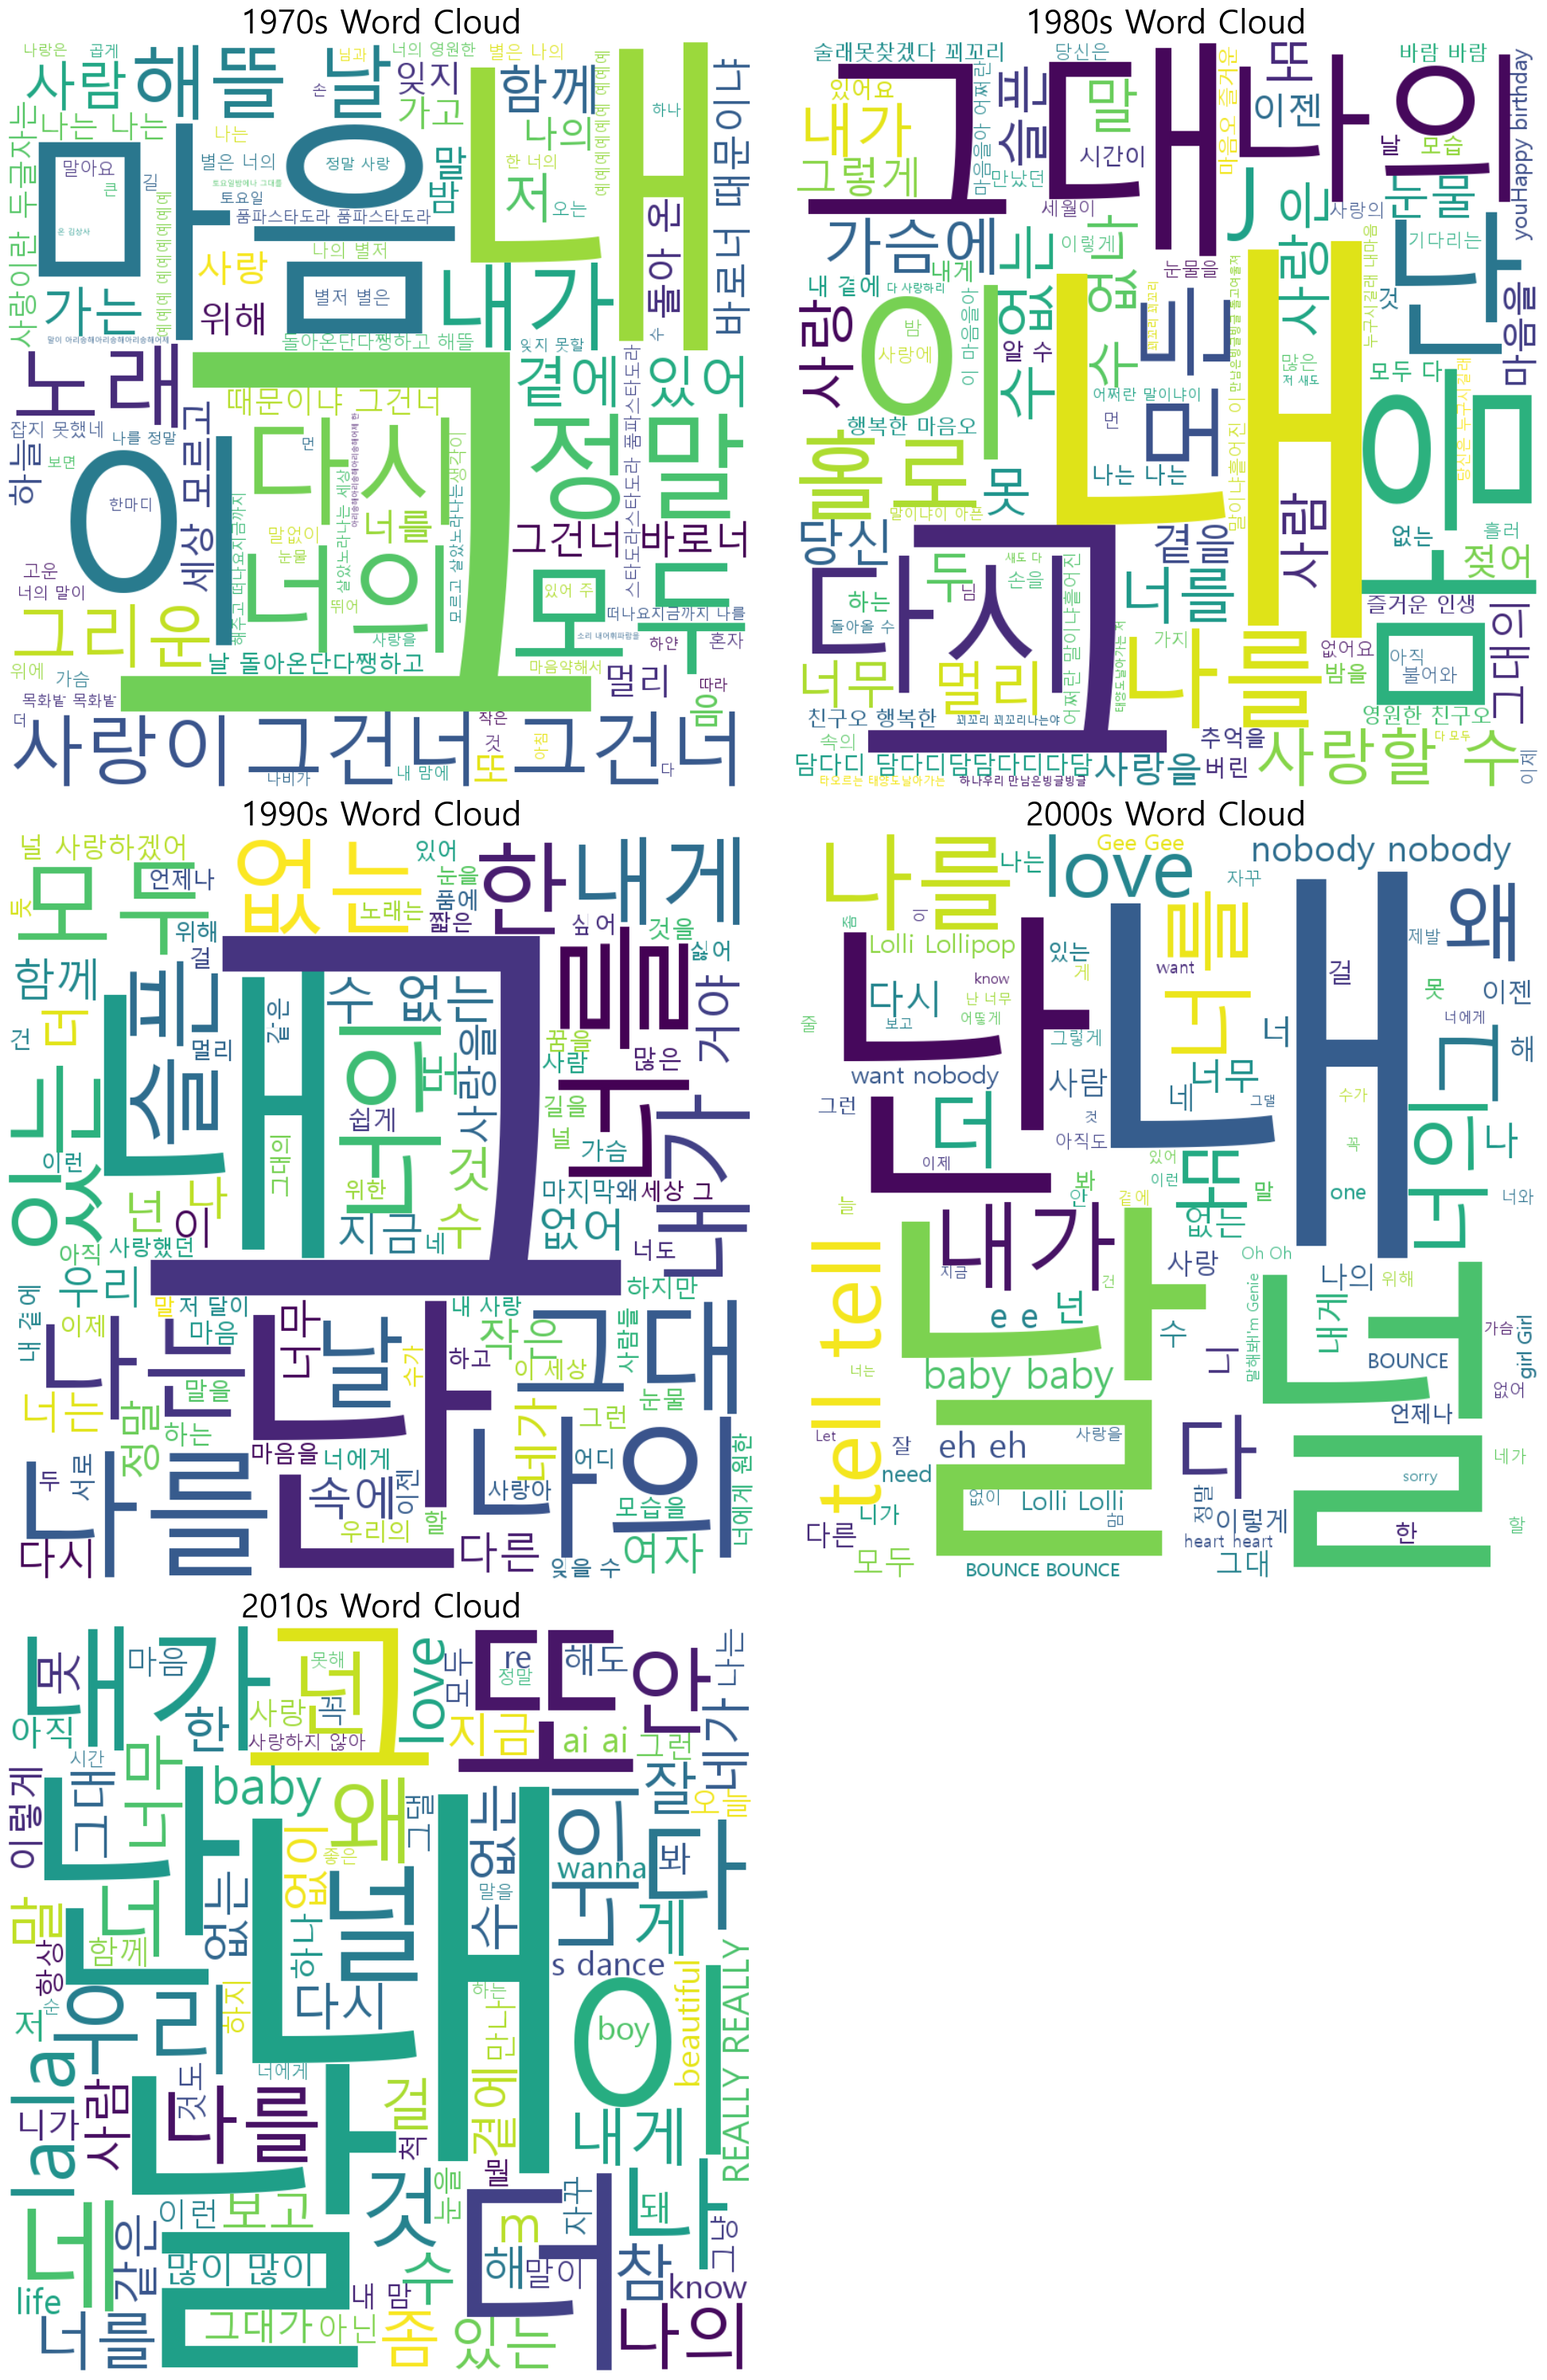

In [4]:
from wordcloud import WordCloud

# 연대별 워드 클라우드 생성 함수
def generate_decade_wordclouds(df):
    decades = sorted(df['decade'].unique())
    n_decades = len(decades)

    # 그래프 레이아웃 설정 (2열로 배치)
    rows = (n_decades + 1) // 2
    fig = plt.figure(figsize=(20, 10 * rows))

    for i, decade in enumerate(decades):
        # 해당 연대 가사 추출 및 합치기
        decade_lyrics = " ".join(df[df['decade'] == decade]['lyrics'].dropna().astype(str))

        # 워드 클라우드 객체 생성
        wc = WordCloud(
            font_path=FONT_PATH,
            background_color='white',
            width=800,
            height=800,
            max_words=100
        ).generate(decade_lyrics)

        # 서브플롯 추가
        ax = fig.add_subplot(rows, 2, i + 1)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f"{decade}s Word Cloud", fontsize=30)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# 분석 실행
generate_decade_wordclouds(df_lyrics)

## 1_3. 한글 텍스트 전처리 (형태소 분석 및 불용어 제거)

### 1_3_1. RAW 빈도 확인 단계 (Human-in-the-loop 준비)

`1_2. 워드 클라우드 생성하기` 단계에서 확인한 워드 클라우드는 아직 정제되지 않은 상태입니다. 이 단계의 결과는 주로 학생들의 실습을 위한 것이며, 실질적인 의미가 없는 조사, 어미, 지칭어 등 불용어가 다수 포함되어 있어 명확한 **주제어를 분류하기 어렵습니다.**

따라서 다음 단계에서는 이러한 불용어를 제거하고, **가치 개념이 명확한 명사류만 필터링**하여 시대별 가치관을 보다 정확하게 분석할 수 있도록 준비할 예정입니다.

In [5]:
from collections import Counter  # 이탈 방지를 위해 최상단에 명시적으로 임포트

def filter_morphemes_raw(text):
    """
    학생들이 국어 문법의 실질 형태소를 확인할 수 있도록 용언(동사, 형용사)을 포함하여 
    명사, 대명사, 어근, 부사 태그만 필터링하여 문자열로 반환합니다.
    """
    if not isinstance(text, str):
        return ""
    try:
        pos_tagged = mecab.pos(text)
        filtered_words = [ 
            word for word, tag in pos_tagged
            # NNG: 일반명사, NNP: 고유명사, NP: 대명사, XR: 어근, MAG: 일반부사, VV: 동사 어간, VA: 형용사 어간
            if tag in ['NNG', 'NNP', 'NP', 'XR', 'MAG', 'VV', 'VA']
        ]
        return " ".join(filtered_words)
    except Exception:
        return ""

def generate_decade_frequency_df(df, column_name, top_n=50):
    """
    공백으로 구분된 단어 컬럼을 분석하여 연대별 단어 빈도를 내림차순으로 정렬한 비교 표(DataFrame)를 생성합니다.
    """
    decades = sorted(df['decade'].unique())
    comparison_dfs = []
    
    for decade in decades:
        decade_df = df[df['decade'] == decade]
        words = []
        
        # 공백 기준으로 단어들을 분리하여 리스트에 추가
        for text in decade_df[column_name].dropna().astype(str):
            words.extend(text.split())
            
        word_counts = Counter(words)
        top_words = word_counts.most_common(top_n)
        
        # 연대별 빈도표 데이터프레임 생성
        df_temp = pd.DataFrame(top_words, columns=[f'단어 ({decade}s)', f'빈도수 ({decade}s)'])
        comparison_dfs.append(df_temp)
        
    return pd.concat(comparison_dfs, axis=1)


In [6]:
# 1. 원시 가사에서 품사 필터링만 적용하여 새로운 컬럼 생성
df_lyrics['raw_filtered_lyrics'] = df_lyrics['lyrics'].apply(filter_morphemes_raw)

print("\n📊 실습 1단계: 1970년대 가사의 무정제 단어 빈도 Top 30 (형태소 필터링만 적용)")
df_raw_comparison = generate_decade_frequency_df(df_lyrics, 'raw_filtered_lyrics', 30)
display(df_raw_comparison[['단어 (1970s)', '빈도수 (1970s)']])



📊 실습 1단계: 1970년대 가사의 무정제 단어 빈도 Top 30 (형태소 필터링만 적용)


,단어 (1970s),빈도수 (1970s)
0,나,165
1,사랑,136
2,너,105
3,마음,84
4,말,75
5,그대,64
6,사람,59
7,밤,54
8,가,51
9,잊,41


In [7]:
print("📊 시대별 무정제 단어 빈도 Top 50 비교 (불용어 제거 전)")
df_raw_comparison = generate_decade_frequency_df(df_lyrics, 'raw_filtered_lyrics', 50)
df_raw_comparison


📊 시대별 무정제 단어 빈도 Top 50 비교 (불용어 제거 전)


,단어 (1970s),빈도수 (1970s),단어 (1980s),빈도수 (1980s),단어 (1990s),빈도수 (1990s),단어 (2000s),빈도수 (2000s),단어 (2010s),빈도수 (2010s)
0,나,165,사랑,265,나,340,나,489,너,389
1,사랑,136,나,248,너,308,너,413,나,383
2,너,105,그대,195,사랑,237,사랑,406,사랑,216
3,마음,84,마음,156,있,180,없,246,없,183
4,말,75,없,121,없,175,날,201,말,174
5,그대,64,당신,85,그대,151,말,192,날,169
6,사람,59,밤,83,날,104,내,166,하,131
7,밤,54,하,80,마음,90,있,139,그대,121
8,가,51,가슴,79,하,89,하,135,있,121
9,잊,41,바람,75,말,87,그대,133,내,118


### 1_3_2. 불용어 정제 및 클리닝 함수 정의

In [8]:
# 학생들이 RAW 빈도표를 보면서 직접 제거할 불용어(Stopwords) 후보를 정의합니다.
STUDENT_STOPWORDS = set([
    # 1. 지시대명사 및 형식적 명사
    '그것', '이것', '저것', '때문', '경우', '정도', '소리', '모습', '가운데', '가지', '녀석',
    # 2. 보편적으로 너무 흔해 변별력이 없는 가요 표현들
    '노래', '가사', '음악', '소리', '대해', '대한', '향해', '위해',
    # 3. 데이터에 따라 제거하고 싶은 구어 표현이나 부사형 어근
    '진짜', '정말', '아주', '매우'
])

In [9]:
def clean_lyrics_with_stopwords(text, stopwords):
    """
    용언 어간의 모호성을 피하기 위해 동사/형용사를 제외하고, 명사/대명사/어근/부사 필터링 및 불용어를 적용합니다.
    """
    if not isinstance(text, str):
        return ""

    try:
        pos_tagged = mecab.pos(text)
        cleaned_words = [ 
            word for word, tag in pos_tagged
            # 국어 문법의 '실질 형태소'에 해당하는 품사들만 남기고, 학생들이 지정한 불용어(Stopwords)는 제거합니다.
            # - NNG: 일반 명사, NNP: 고유 명사, NP: 대명사, XR: 어근, MAG: 일반 부사 (동사 VV, 형용사 VA는 제외)
            if tag in ['NNG', 'NNP', 'NP', 'XR', 'MAG'] and word not in stopwords
        ]
        return " ".join(cleaned_words)
    except Exception:
        return ""


In [10]:
# 데이터프레임 전체에 정제 기능 적용
print("🧹: 학생들이 선정한 불용어 사전을 적용하여 가사를 정제합니다...")
df_lyrics['cleaned_lyrics'] = df_lyrics['lyrics'].apply(lambda x: clean_lyrics_with_stopwords(x, STUDENT_STOPWORDS))
print("✅ 정제된 가사 데이터('cleaned_lyrics' 컬럼)가 성공적으로 준비되었습니다.\n")

# 정제 후 빈도표 출력
print("📊 시대별 정제 단어 빈도 Top 50 비교 (불용어 및 동사/형용사 제거 후)")
df_clean_comparison = generate_decade_frequency_df(df_lyrics, 'cleaned_lyrics', 50)
display(df_clean_comparison)


🧹: 학생들이 선정한 불용어 사전을 적용하여 가사를 정제합니다...


✅ 정제된 가사 데이터('cleaned_lyrics' 컬럼)가 성공적으로 준비되었습니다.

📊 시대별 정제 단어 빈도 Top 50 비교 (불용어 및 동사/형용사 제거 후)


,단어 (1970s),빈도수 (1970s),단어 (1980s),빈도수 (1980s),단어 (1990s),빈도수 (1990s),단어 (2000s),빈도수 (2000s),단어 (2010s),빈도수 (2010s)
0,나,163,사랑,265,나,333,나,474,너,387
1,사랑,136,나,244,너,308,너,413,나,377
2,너,105,그대,195,사랑,237,사랑,406,사랑,216
3,마음,84,마음,156,그대,151,날,195,말,167
4,말,74,당신,85,날,102,말,191,날,167
5,그대,64,밤,83,마음,90,내,160,그대,121
6,사람,59,가슴,79,말,85,그대,133,내,118
7,밤,54,바람,75,속,84,사람,123,우리,110
8,당신,38,말,68,꿈,71,너무,107,더,109
9,날,35,너,59,우리,68,맘,104,다,104


In [11]:
def run_era_deep_analysis(df, target_decade):
    """
    특정 연대의 정제 데이터를 기반으로 워드 클라우드와 주요 키워드 점유율(Pie Chart)을
    하나의 화면에 정교하게 시각화하여 학생들에게 시각적인 인사이트를 전달합니다.
    """
    decade_data = df[df['decade'] == target_decade]['cleaned_lyrics'].dropna()
    merged_text = " ".join(decade_data)

    if not merged_text.strip():
        print(f"⚠️ {target_decade}년대의 정제 가사 데이터가 비어 있습니다. 불용어 사전을 너무 강하게 설정했는지 확인하세요.")
        return

    # 1) 워드 클라우드 데이터 생성
    wordcloud = WordCloud(
        font_path=FONT_PATH,
        background_color='white',
        width=800,
        height=800,
        max_words=80,
        colormap='coolwarm', # 가사의 정조에 맞춘 디자인 테마
        collocations=False
    ).generate(merged_text)

    # 2) 파이 차트용 상위 10개 핵심 가치 키워드 및 빈도 계산
    words_list = merged_text.split()
    word_counts = Counter(words_list)
    top_10_values = word_counts.most_common(10)

    labels = [item[0] for item in top_10_values]
    sizes = [item[1] for item in top_10_values]

    # 3) 시각화 그리기 (1행 2열 레이아웃)
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Left Plot: Word Cloud
    axes[0].imshow(wordcloud, interpolation='bilinear')
    # 이모지 제거: 🎬 -> 핵심
    axes[0].set_title(f"[핵심] [{target_decade}년대] 핵심 정제 워드 클라우드", fontsize=18, fontweight='bold', pad=15)
    axes[0].axis('off')

    # Right Plot: Pie Chart (점유율 시각화)
    color_palette = ['#4A90E2', '#357ABD', '#7B9FE9', '#A5C1F5', '#D2E1FC']
    wedges, texts, autotexts = axes[1].pie(
        sizes,
        labels=labels,
        autopct='%1.1f%%',
        startangle=140,
        colors=color_palette,
        textprops={'fontsize': 14},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5, 'antialiased': True}
    )

    for autotext in autotexts:
        autotext.set_fontsize(13)
        autotext.set_weight('bold')
        autotext.set_color('white')

    # 이모지 제거: 📊 -> 분석
    axes[1].set_title(f"[분석] [{target_decade}년대] 대표 가치관 점유율 (Top 10)", fontsize=18, fontweight='bold', pad=15)

    plt.tight_layout()
    plt.show()

🎬 4단계: 모든 연대의 정제 완료된 시각화 분석을 출력합니다.


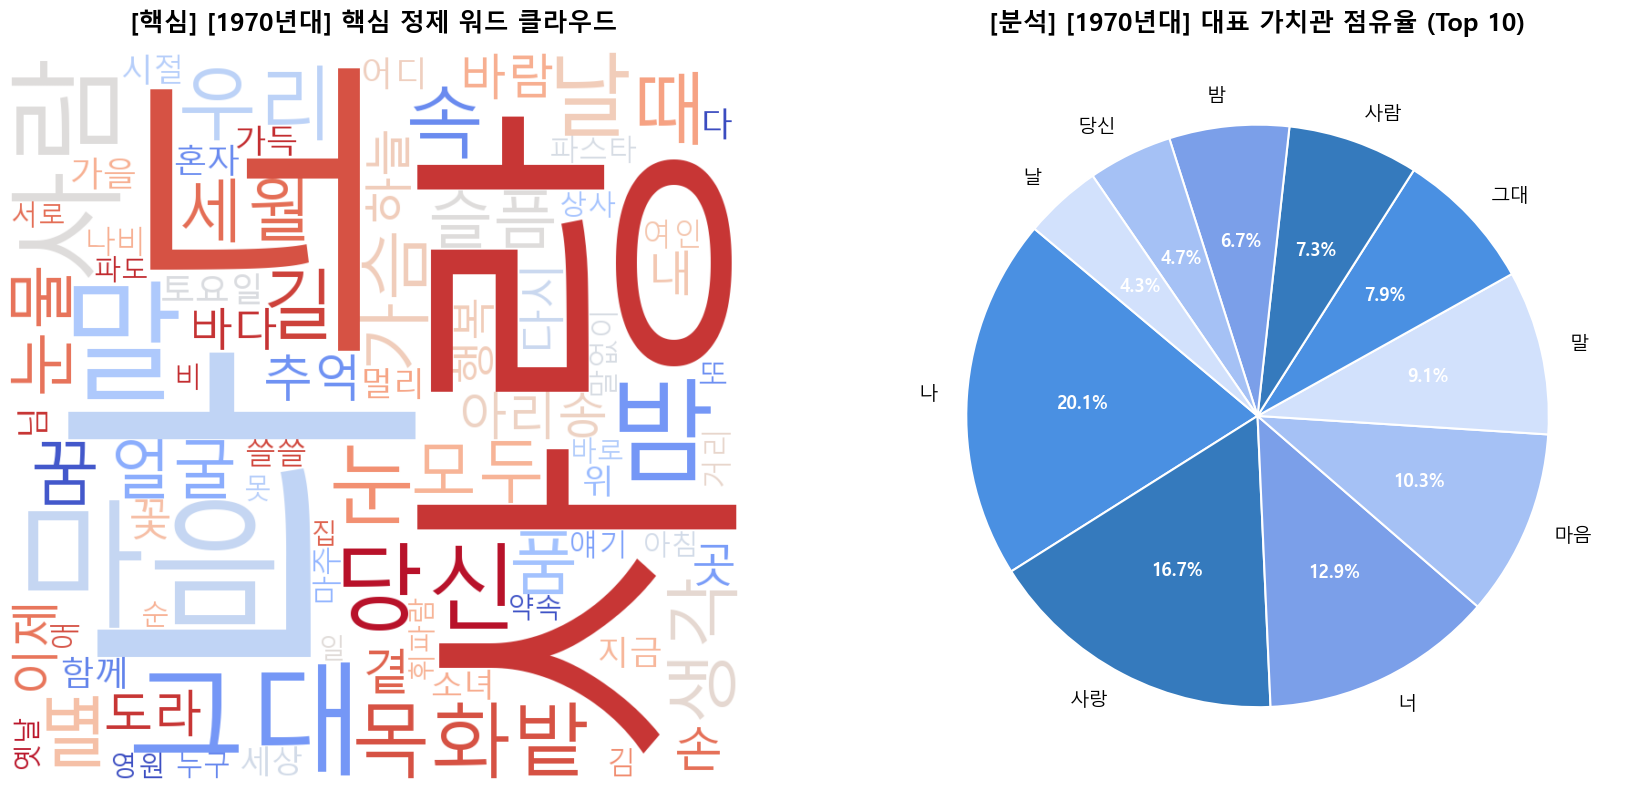

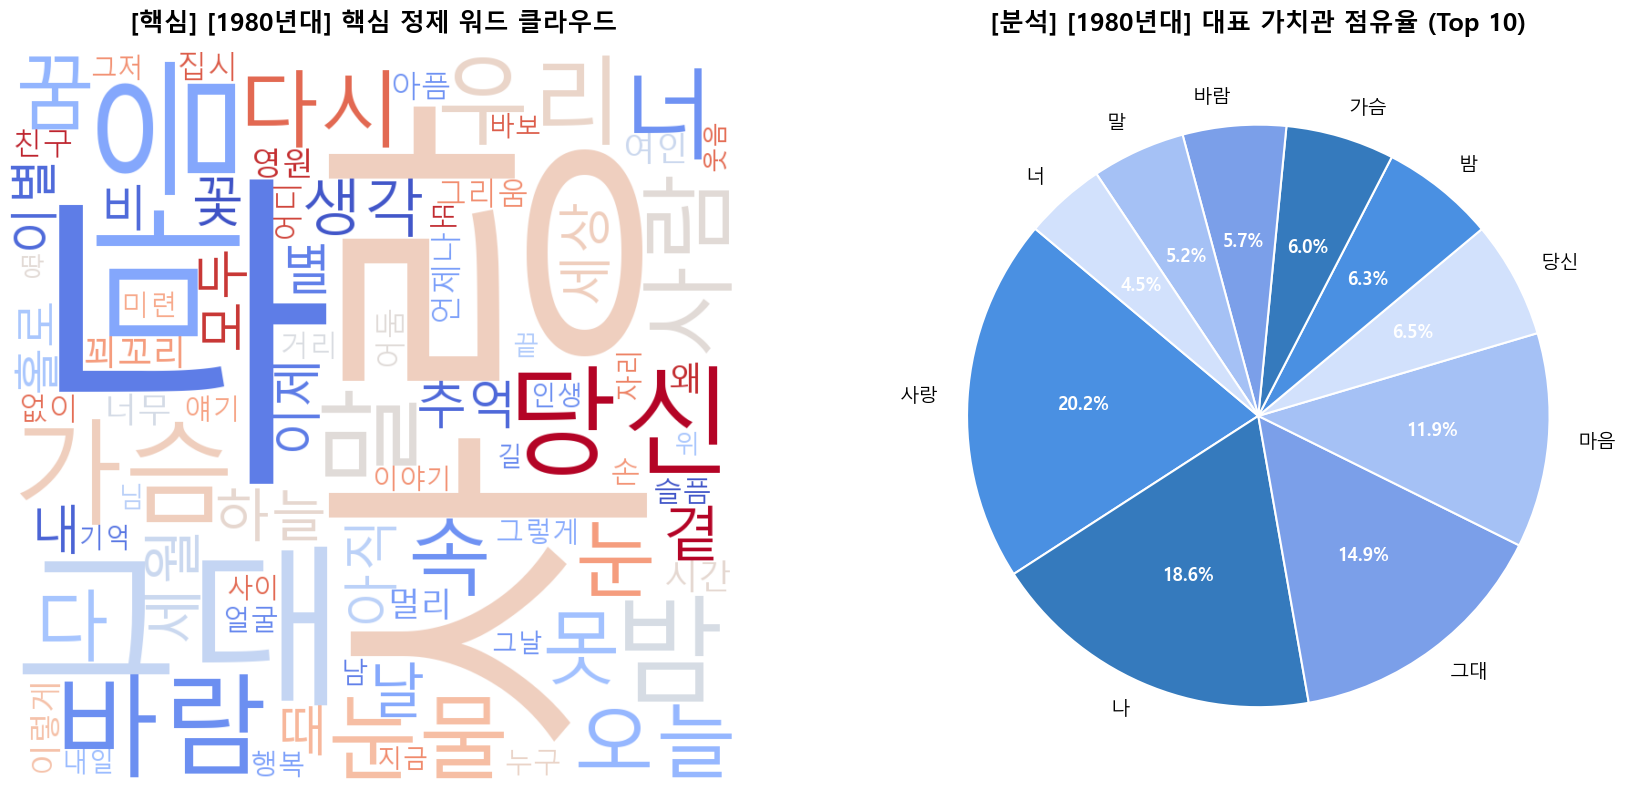

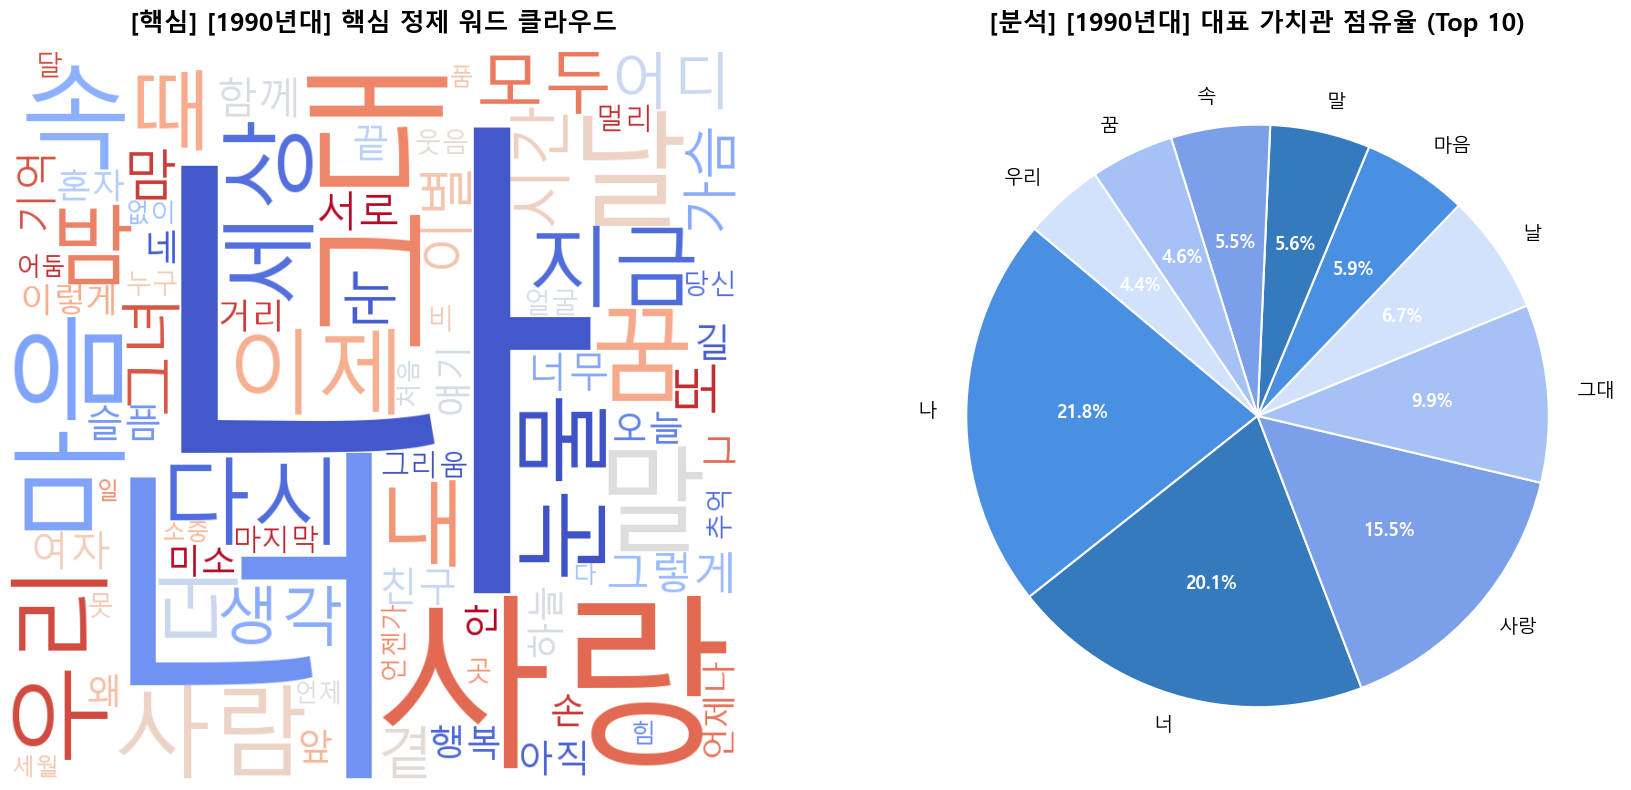

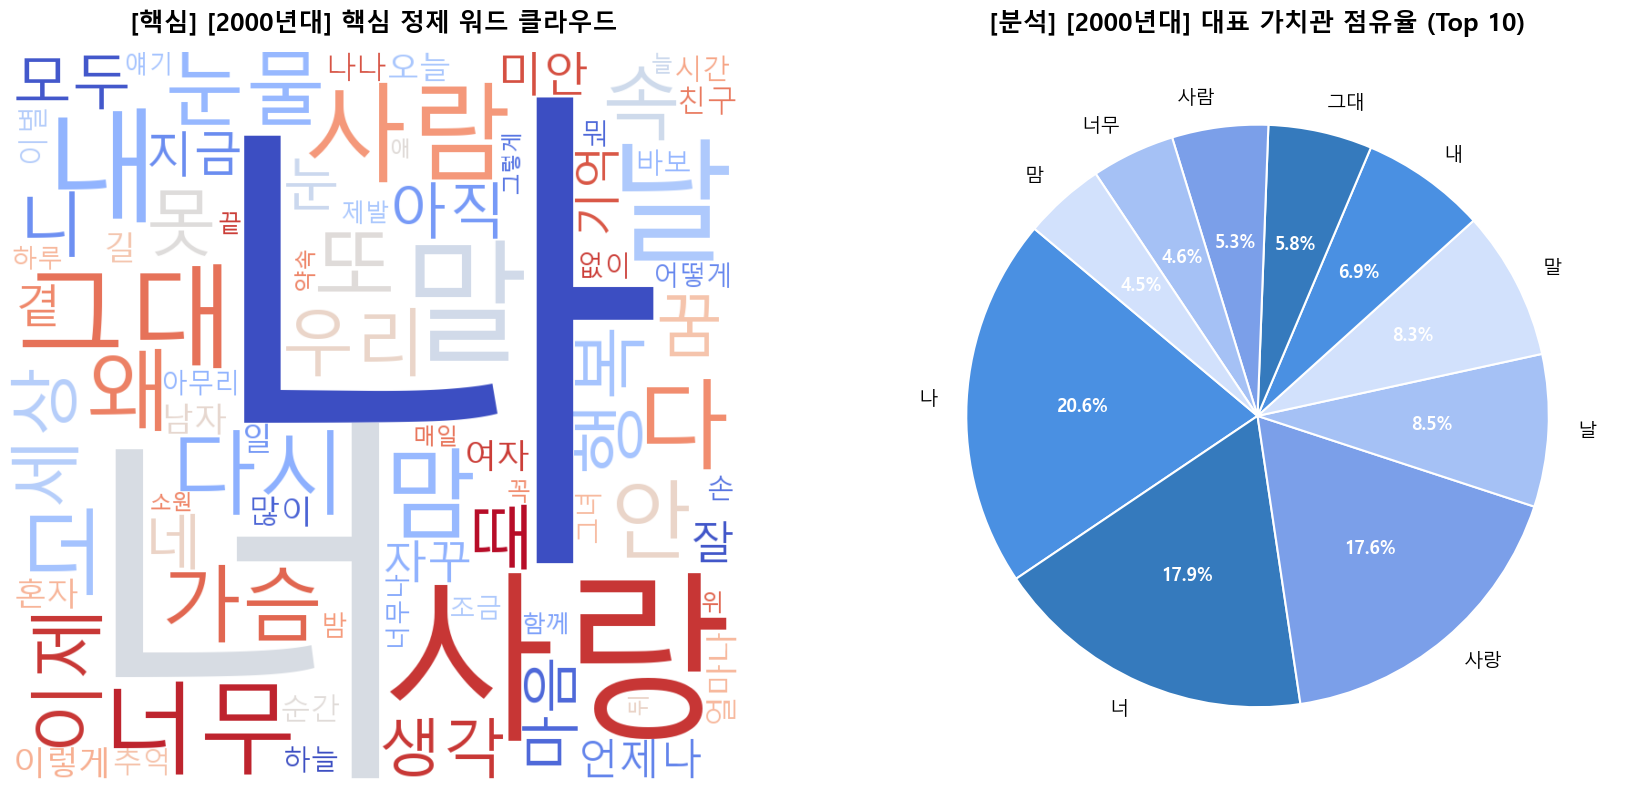

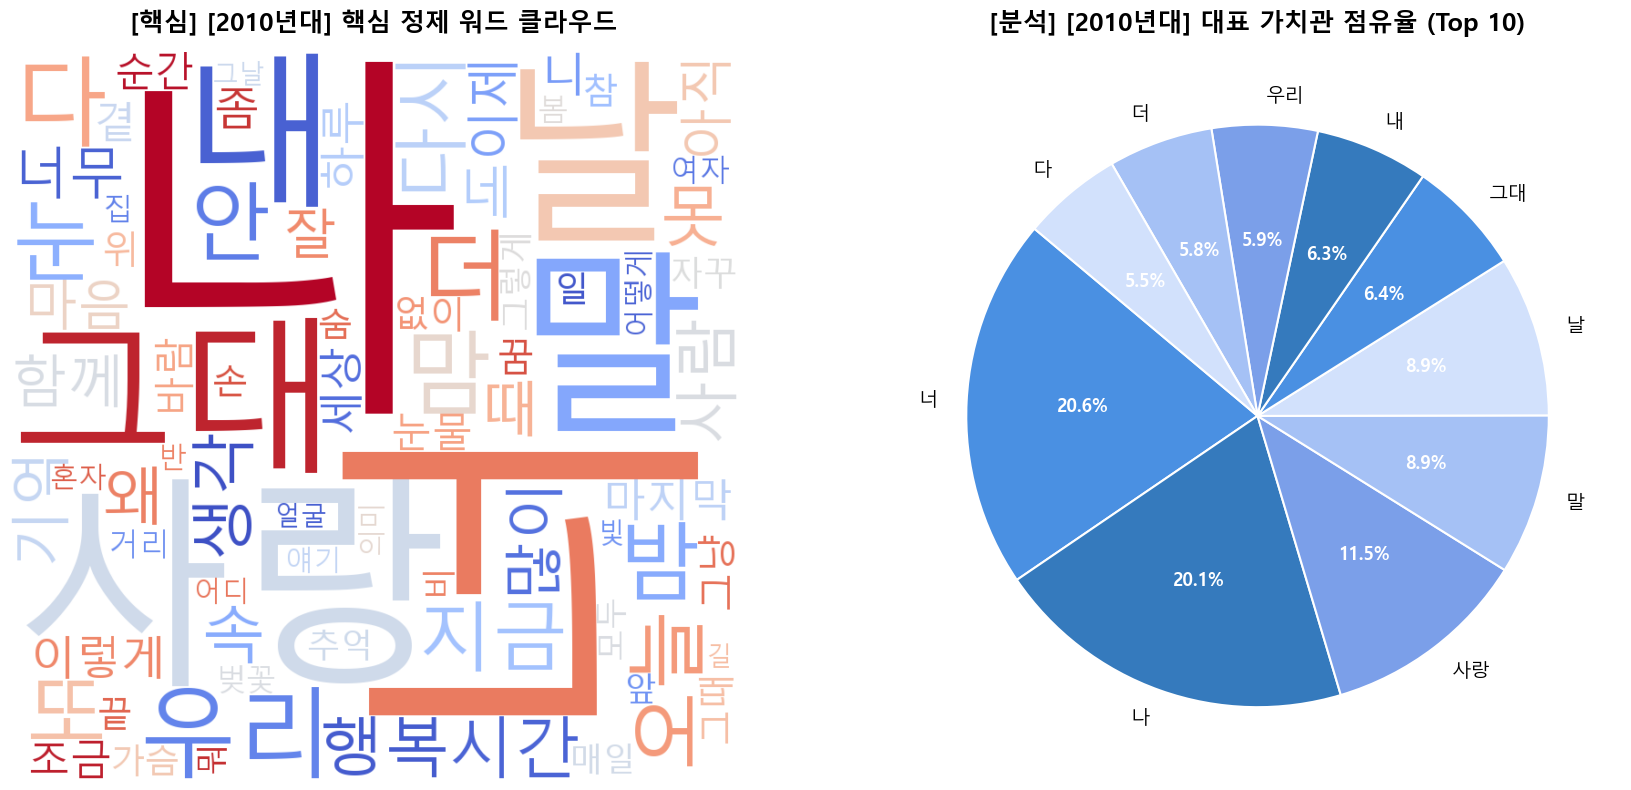

In [12]:
print("🎬 4단계: 모든 연대의 정제 완료된 시각화 분석을 출력합니다.")

for decade in DECADES:
    run_era_deep_analysis(df_lyrics, decade)


# ==========================================
#2. **시대 흐름에 따른 변화 분석**
# ==========================================

- 누적 영역 차트 (Stacked Area Chart): * 여러 가치관(개인주의, 공동체주의, 물질만능주의, 낭만주의 등)의 비중 변화를 시대순으로 누적하여 보여줍니다.
- 멀티 라인 차트 (Multi-Line Chart): * 특정 키워드(예: '꿈', '돈', '우리')의 빈도수를 Y축에 놓고 연도별 변화를 비교합니다. 거시경제 지표(GDP 등)와 가사 속 긍정 지수의 상관관계를 시각화하는 일반사회 교과 융합 활동으로 확장 가능합니다.


In [13]:
import os
import urllib.request
import urllib.parse
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm # Explicitly import fm here

# ==========================================
# 0. 분석 환경 구축 및 데이터 로드 (안정성 강화)
# ==========================================

print("🚀 1단계: 분석 환경을 마련하고 대중가요 가사 데이터를 로드합니다.")

# 1) MeCab 형태소 분석기 설치 및 로드
try:
    from mecab import MeCab
    mecab = MeCab()
    print("✅ MeCab 형태소 분석기가 준비되었습니다.")
except ImportError:
    print("MeCab 라이브러리를 설치합니다...")
    os.system("pip install python-mecab-ko konlpy")
    from mecab import MeCab
    mecab = MeCab()
    print("✅ MeCab 설치 및 초기화 완료!")

# 2) 한글 깨짐 방지를 위한 나눔 폰트 설치 및 한글 환경 구성 (OS별 자동 대응)
import platform
if os.name == 'nt' or platform.system() == 'Windows':
    FONT_PATH = "C:/Windows/Fonts/malgun.ttf"
    plt.rcParams['font.family'] = ['Malgun Gothic', 'sans-serif']
else:
    FONT_PATH = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    if not os.path.exists(FONT_PATH):
        print("한글 나눔 폰트를 설치합니다... (시간이 조금 걸릴 수 있습니다)")
        os.system("apt-get update -qq && apt-get install fonts-nanum -qq")
        fm.fontManager.addfont(FONT_PATH) # Use fm for consistency
    plt.rcParams['font.family'] = ['NanumGothic', 'sans-serif']

plt.rcParams['axes.unicode_minus'] = False
print("✅ 한글 폰트 설정 완료 (이모지 폰트 경고 방지 목적)")

# 3) 데이터셋 다운로드 및 로드 (GitHub 연동)
GITHUB_URL = 'https://raw.githubusercontent.com/jungho-kim0713/colab_data-analyisis/main/lyrics_by_era.csv'
LOCAL_FILENAME = 'lyrics_by_era.csv'

try:
    df_lyrics = pd.read_csv(LOCAL_FILENAME)
    print(f"✅ 기존 파일 로드 완료! (총 {len(df_lyrics)}곡)")
except Exception:
    print("GitHub 저장소에서 최신 가사 데이터셋을 다운로드합니다...")
    safe_url = urllib.parse.quote(GITHUB_URL, safe=':/?&=')
    urllib.request.urlretrieve(safe_url, LOCAL_FILENAME)
    df_lyrics = pd.read_csv(LOCAL_FILENAME)
    print(f"✅ 다운로드 및 로드 완료! (총 {len(df_lyrics)}곡)")

# 데이터프레임 전체에 정제 기능 적용
print("🧹: 학생들이 선정한 불용어 사전을 적용하여 가사를 정제합니다...")
df_lyrics['cleaned_lyrics'] = df_lyrics['lyrics'].apply(lambda x: clean_lyrics_with_stopwords(x, STUDENT_STOPWORDS))


🚀 1단계: 분석 환경을 마련하고 대중가요 가사 데이터를 로드합니다.
✅ MeCab 형태소 분석기가 준비되었습니다.
✅ 한글 폰트 설정 완료 (이모지 폰트 경고 방지 목적)
✅ 기존 파일 로드 완료! (총 500곡)
🧹: 학생들이 선정한 불용어 사전을 적용하여 가사를 정제합니다...


## 2_1. 가치관 분류 및 시대별 변화 분석 준비

여러 가치관(예: 개인주의, 공동체주의, 물질만능주의)의 변화를 분석하기 위해, 각 가치관을 대표하는 핵심 키워드들을 정의합니다. 이후 이 키워드들의 연대별 출현 빈도를 계산하여 시대 흐름에 따른 가치관의 상대적 비중 변화를 시각화합니다.

In [14]:
# [사회학적 가치 모델 구축]
# 학생들이 시대를 해석할 주요 가치 프레임을 4가지로 분류하고 각 가치를 대변하는 핵심 키워드 매핑을 정의합니다.
# (수업 중 학생들과 토의하여 각 가치관을 대표하는 단어 사전을 변경해 보도록 지도하면 훌륭한 맞춤형 탐구지가 됩니다.)
VALUE_CATEGORIES = {
    '공동체주의 (Collectivism)': ['우리', '가족', '고향', '친구', '나라', '함께', '사람', '부모', '세상'],
    '자아/개인주의 (Individualism)': ['나', '내게', '자유', '스스로', '인생', '자아', '마이', '혼자'],
    '물질/성공주의 (Materialism)': ['돈', '성공', '최고', '스타', '부자', '차', '빌딩', '유명'],
    '낭만/자연정서 (Romanticism)': ['꿈', '사랑', '바람', '눈물', '추억', '노래', '하늘', '그대', '정', '별', '꽃', '밤', '빛']
}

## 2_2. 가치관 시대 흐름 시각화 (누적 영역 차트)

계산된 연대별 가치관 키워드 빈도를 바탕으로, 각 가치관이 전체에서 차지하는 비중 변화를 누적 영역 차트로 시각화합니다. 이를 통해 어떤 가치관이 특정 시대에 강하게 나타나고 약해지는지 한눈에 파악할 수 있습니다.

In [15]:
from collections import Counter # Counter를 임포트

def calculate_value_percentages(df, value_model):
    """
    주어진 데이터프레임과 가치 모델을 기반으로 시대별 가치관 키워드의 상대적 백분율을 계산합니다.
    각 시대의 전체 'cleaned_lyrics'에서 정의된 가치관 키워드들의 총 출현 빈도에 대한 각 가치관의 비율을 계산합니다.
    """
    decades = sorted(df['decade'].unique())
    category_data = []

    for decade in decades:
        decade_data = df[df['decade'] == decade]['cleaned_lyrics'].dropna()
        all_words_in_decade = " ".join(decade_data).split()
        word_counts = Counter(all_words_in_decade)

        decade_percentages = {'decade': decade}
        total_categorized_words_in_decade = 0

        # 1. 먼저 각 카테고리의 원시 빈도와 전체 카테고리 단어의 총합을 계산합니다.
        category_raw_counts = {}
        for category, keywords in value_model.items():
            count = sum(word_counts[kw] for kw in keywords)
            category_raw_counts[category] = count
            total_categorized_words_in_decade += count

        # 2. 그런 다음 total_categorized_words_in_decade에 대한 백분율을 계산합니다.
        for category, count in category_raw_counts.items():
            percentage = (count / total_categorized_words_in_decade * 100) if total_categorized_words_in_decade > 0 else 0
            decade_percentages[category] = percentage
        category_data.append(decade_percentages)
    return pd.DataFrame(category_data)

def plot_stacked_value_paradigm(df_percentages, value_model):
    """
    계산된 가치관별 백분율 DataFrame을 누적 영역 차트로 시각화합니다.
    """
    decades = sorted(df_percentages['decade'].unique())
    categories = list(value_model.keys())

    # 연도별 카테고리 비율 저장 행렬 (데이터프레임에서 직접 가져옴)
    era_category_matrix = {cat: df_percentages[cat].tolist() for cat in categories}

    # 누적 영역 차트 그리기
    plt.figure(figsize=(14, 8.5))

    y_data = [era_category_matrix[cat] for cat in categories]

    # 시각적 전달력이 뛰어난 플랫 UI 디자인 컬러 팔레트 적용
    colors = ['#5DADE2', '#48C9B0', '#F4D03F', '#EC7063']

    plt.stackplot(decades, y_data, labels=categories, colors=colors, alpha=0.85)

    plt.title("시대적 가치관 패러다임의 비중 변화 추이 (가사 기준 가치 범주별 상대 비중 분석)",
              fontsize=18, fontweight='bold', pad=22)
    plt.xlabel("연대 (Decade)", fontsize=13, fontweight='bold', labelpad=12)
    plt.ylabel("가치관 카테고리 내 상대적 점유율 (%)", fontsize=13, fontweight='bold', labelpad=12)
    plt.xticks(decades, [f"{d}년대" for d in decades], fontsize=11)
    plt.ylim(0, 100)

    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.legend(loc='upper right', fontsize=12, frameon=True, facecolor='white', shadow=True)

    # 차트 내에 각 가치관별 실제 % 비율을 텍스트로 오버레이 (학생들의 통계 해석 가이드라인 역할)
    for idx, decade in enumerate(decades):
        cumulative_y = 0
        for cat in categories:
            val = era_category_matrix[cat][idx]
            if val > 1:  # 비율이 1% 이상인 의미 있는 크기의 영역에만 비율을 표시
                plt.text(decade, cumulative_y + (val/2), f"{val:.1f}%",
                         ha='center', va='center', fontsize=11, fontweight='bold', color='black')
            cumulative_y += val

    plt.tight_layout()
    plt.show()

# df_value_percentages 계산
df_value_percentages = calculate_value_percentages(df_lyrics, VALUE_CATEGORIES)
df_value_percentages


,decade,공동체주의 (Collectivism),자아/개인주의 (Individualism),물질/성공주의 (Materialism),낭만/자연정서 (Romanticism)
0,1970,18.552632,24.605263,1.710526,55.131579
1,1980,13.453973,20.928403,0.393391,65.224233
2,1990,19.811321,28.694969,0.471698,51.022013
3,2000,18.378713,31.930693,0.618812,49.071782
4,2010,20.890937,31.105991,0.844854,47.158218


 실습 2-2단계: [방법 A] 4대 가치 키워드 합산 대비 상대 비율 누적 차트를 출력합니다.


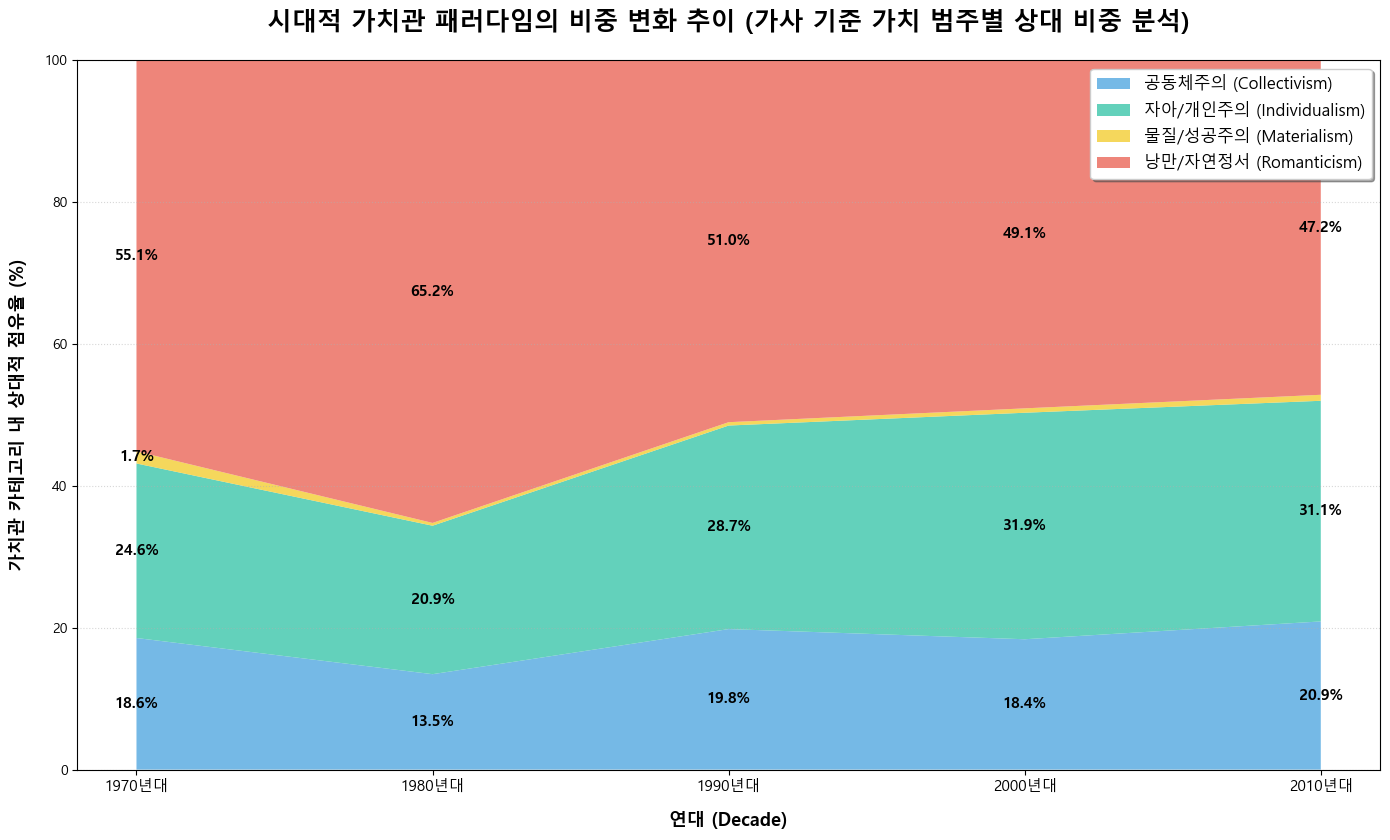

In [16]:
print(" 실습 2-2단계: [방법 A] 4대 가치 키워드 합산 대비 상대 비율 누적 차트를 출력합니다.")

# 2. 계산된 백분율을 기반으로 누적 영역 차트 시각화
plot_stacked_value_paradigm(df_value_percentages, VALUE_CATEGORIES)



📊 실습 2-3단계: [방법 B] 연대별 전체 단어 수 대비 절대적 점유율 누적 영역 차트를 출력합니다.


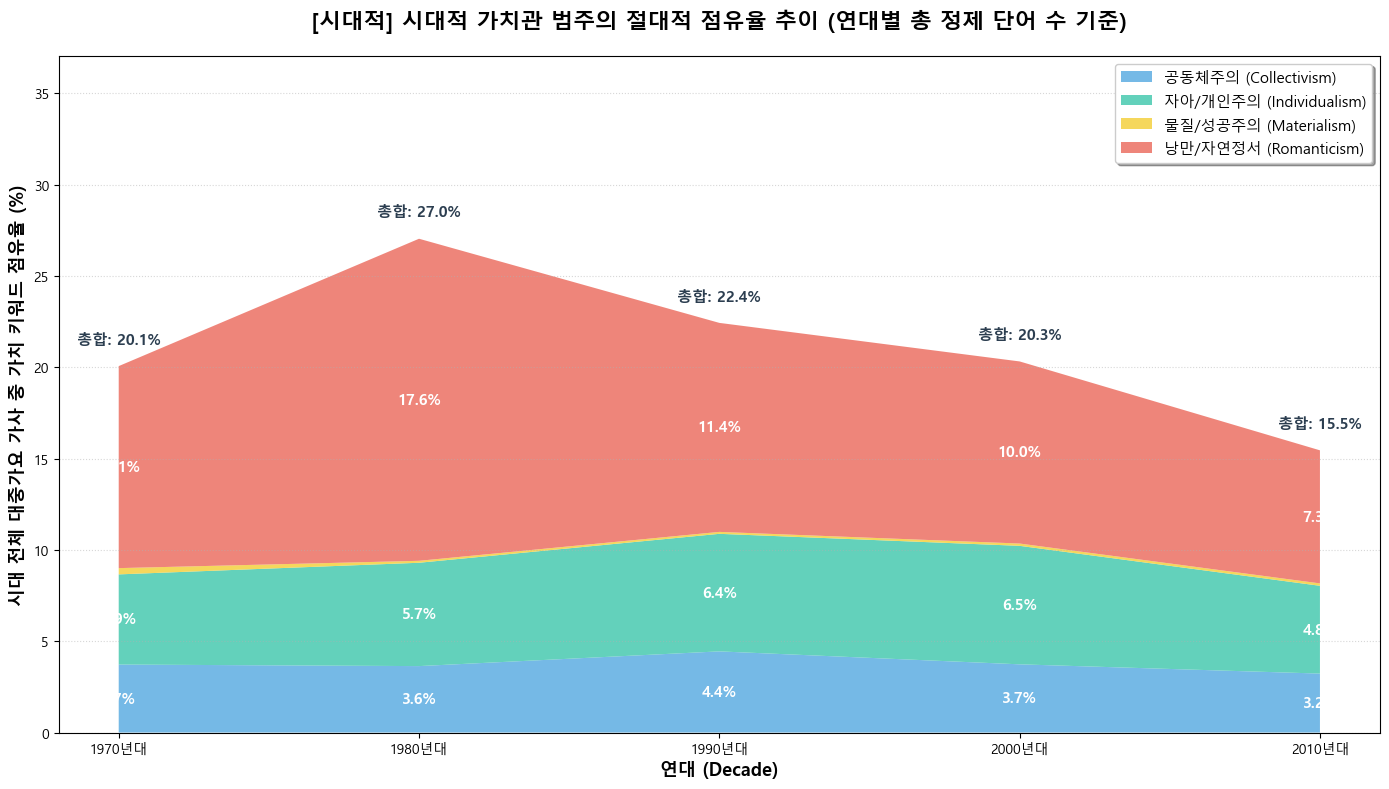

In [17]:
def analyze_value_paradigm_absolute_stacked(df, value_model):
    """
    해당 연대의 모든 정제 단어 총량(cleaned_lyrics 내 모든 명사 수)을 '분모'로 삼아 계산합니다.
    Y축 최대치가 100%로 고정되지 않고, '이 시대 대중문화 전체 가사에서 우리가 정의한 핵심 가치관 단어들이
    차지하는 절대 점유율이 실제로 얼마나 되는지' 계량적으로 보여줍니다.
    """
    decades = sorted(df['decade'].unique())
    categories = list(value_model.keys())
    era_category_matrix = {cat: [] for cat in categories}

    for decade in decades:
        decade_data = df[df['decade'] == decade]['cleaned_lyrics'].dropna()
        all_words = " ".join(decade_data).split()

        # 분모 계산: 해당 연대의 전체 정제 명사/어근의 개수 (이것이 100% 기준이 됨)
        total_words_in_decade = len(all_words)
        word_counts = Counter(all_words)

        for cat in categories:
            keywords = value_model[cat]
            # Exact Token Matching 방식으로 오류 차단 및 정확한 단어 일치만 카운트
            cat_sum = sum(word_counts[kw] for kw in keywords)

            # 전체 정제 단어 대비 해당 가치관 범주의 출현율(%) 계산
            percentage = (cat_sum / total_words_in_decade * 100) if total_words_in_decade > 0 else 0
            era_category_matrix[cat].append(percentage)

    plt.figure(figsize=(14, 8))
    y_data = [era_category_matrix[cat] for cat in categories]
    colors = ['#5DADE2', '#48C9B0', '#F4D03F', '#EC7063']

    plt.stackplot(decades, y_data, labels=categories, colors=colors, alpha=0.85)

    # 이모지 제거: 🏕️ -> 시대적
    plt.title("[시대적] 시대적 가치관 범주의 절대적 점유율 추이 (연대별 총 정제 단어 수 기준)", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("연대 (Decade)", fontsize=13, fontweight='bold')

    # 텍스트 하이라이트 문구 반영
    plt.ylabel("시대 전체 대중가요 가사 중 가치 키워드 점유율 (%)", fontsize=13, fontweight='bold')
    plt.xticks(decades, [f"{d}년대" for d in decades])

    # [설계 포인트] Y축의 최대 범위는 시대별 누적 점유율의 최대값에 맞게 유동적으로 보여주거나
    # 전체의 일부분임을 강조하기 위해 적절하게 상단 여유 공간을 둡니다. (예: 40% 혹은 50%)
    max_cumulative = max(sum(era_category_matrix[cat][idx] for cat in categories) for idx in range(len(decades)))
    plt.ylim(0, min(100, max_cumulative + 10))

    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.legend(loc='upper right', fontsize=11, frameon=True, facecolor='white', shadow=True)

    # 각 영역 내부에 절대 점유율 수치를 텍스트로 표기
    for idx, decade in enumerate(decades):
        cumulative_y = 0
        for cat in categories:
            val = era_category_matrix[cat][idx]
            if val > 1.0:  # 비율이 1% 이상인 의미 있는 크기에만 텍스트 표시
                plt.text(decade, cumulative_y + (val/2), f"{val:.1f}%", ha='center', va='center', fontsize=11, fontweight='bold', color='white')
            cumulative_y += val

    # 전체 가치관 단어들이 차지하는 총합 점유율을 차트 상단에 표시하여 데이터 이해를 도움
    for idx, decade in enumerate(decades):
        total_sum = sum(era_category_matrix[cat][idx] for cat in categories)
        plt.text(decade, total_sum + 1, f"총합: {total_sum:.1f}%", ha='center', va='bottom', fontsize=11, fontweight='bold', color='#2C3E50')

    plt.tight_layout()
    plt.show()

print("\n📊 실습 2-3단계: [방법 B] 연대별 전체 단어 수 대비 절대적 점유율 누적 영역 차트를 출력합니다.")
analyze_value_paradigm_absolute_stacked(df_lyrics, VALUE_CATEGORIES)

## 2_3. 거시경제 지표(GDP)와 가사 속 긍정 지수의 상관관계 (멀티 라인 차트)


 실습: 가치관 키워드 변화 추이 및 GDP 비교 분석 시각화를 실행합니다.
 [통계 데이터 계산 현황] 연대별 총 단어 수 대비 키워드 빈도 추출:
---------------------------------------------------------------------------
🔹 1970년대: 총 정제 단어 수 = 3,788개
   - '우리': 실제 빈도 = 31회 -> 단어 10,000개당 빈도 = 81.84회
   - '꿈': 실제 빈도 = 24회 -> 단어 10,000개당 빈도 = 63.36회
   - '돈': 실제 빈도 = 0회 -> 단어 10,000개당 빈도 = 0.00회
---------------------------------------------------------------------------
🔹 1980년대: 총 정제 단어 수 = 4,701개
   - '우리': 실제 빈도 = 57회 -> 단어 10,000개당 빈도 = 121.25회
   - '꿈': 실제 빈도 = 43회 -> 단어 10,000개당 빈도 = 91.47회
   - '돈': 실제 빈도 = 0회 -> 단어 10,000개당 빈도 = 0.00회
---------------------------------------------------------------------------
🔹 1990년대: 총 정제 단어 수 = 5,671개
   - '우리': 실제 빈도 = 68회 -> 단어 10,000개당 빈도 = 119.91회
   - '꿈': 실제 빈도 = 71회 -> 단어 10,000개당 빈도 = 125.20회
   - '돈': 실제 빈도 = 1회 -> 단어 10,000개당 빈도 = 1.76회
---------------------------------------------------------------------------
🔹 2000년대: 총 정제 단어 수 = 7,953개
   - '우리': 실제 빈도 = 60회 -> 단어 10,000개당 빈도 = 75.44회
   -

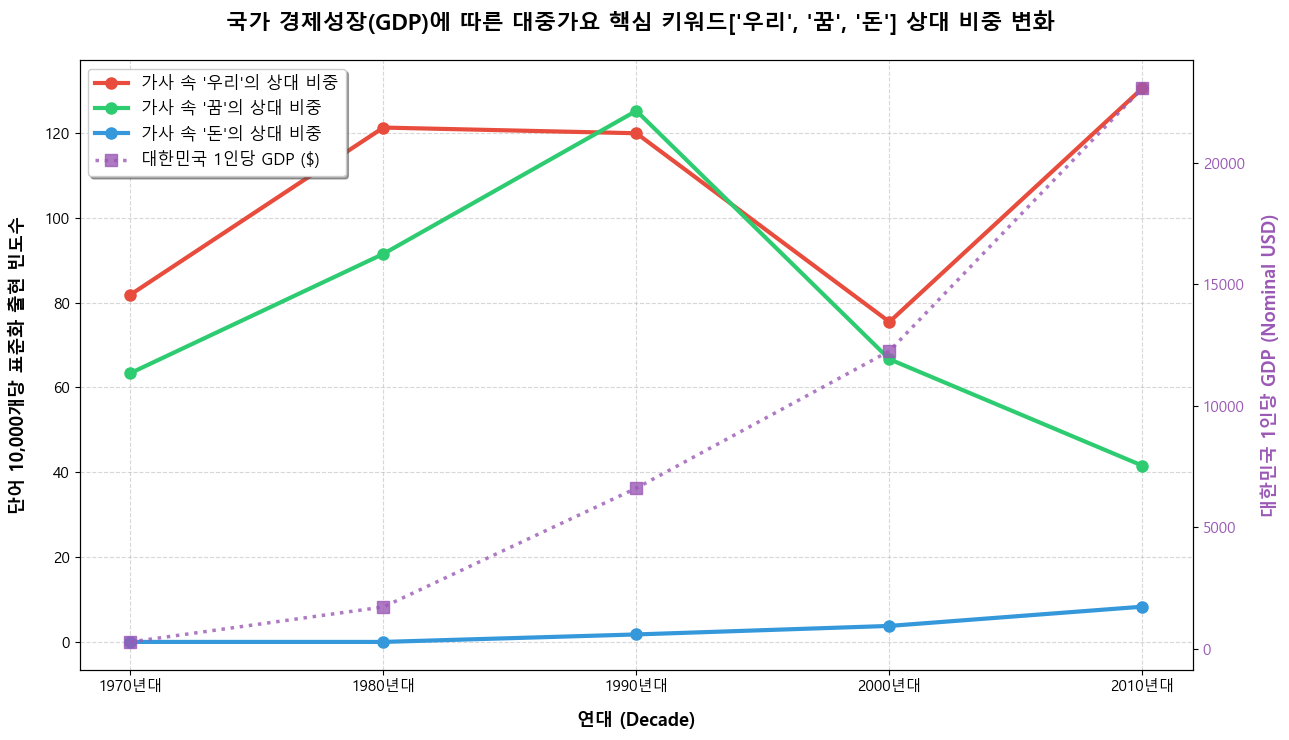

In [18]:
# [일반사회/경제 융합 탐구 데이터]
# 대한민국 역대 1인당 nominal GDP 추이 (역사적 실측치, 단위: USD)
KOREAN_GDP_TREND = {
    1970: 275,
    1980: 1714,
    1990: 6610,
    2000: 12256,
    2010: 23083
}

# [수업 활동 가이드]
# 학생들과 모둠 토론을 거쳐 분석해볼 "대표적인 핵심 키워드 목록"을 입력받습니다.
# 예: ['우리', '꿈', '돈'] 또는 ['나', '정', '사랑']
STUDENT_SELECTED_KEYWORDS = ['우리', '꿈', '돈']

def analyze_keyword_trends_with_gdp(df, target_keywords):
    """
    [선생님 제안 공식 적용]
    각 연도(decade)의 총 단어 수를 분모로 하고, 특정 키워드 출현 횟수를 분자로 두어 상대 비중을 계산합니다.
    Y축 스케일 최적화를 위해 '단어 10,000개당 출현 빈도수' 단위로 환산하여 비교 분석 및 GDP 이중 축 차트를 그립니다.
    """
    decades = sorted(df['decade'].unique())
    trend_data = {kw: [] for kw in target_keywords}

    print(" [통계 데이터 계산 현황] 연대별 총 단어 수 대비 키워드 빈도 추출:")
    print("-" * 75)

    for decade in decades:
        # 1) 해당 연대의 모든 가사 텍스트를 하나로 결합
        decade_data = df[df['decade'] == decade]['cleaned_lyrics'].dropna()
        all_words = " ".join(decade_data).split()

        # [선생님 설계의 핵심 분모] 해당 연대의 가요 전체 정제 단어 수
        total_word_count = len(all_words)

        # 2) 각 단어의 빈도 계산
        word_counts = Counter(all_words)

        print(f"🔹 {decade}년대: 총 정제 단어 수 = {total_word_count:,}개")

        for kw in target_keywords:
            kw_raw_count = word_counts[kw]

            # [상대 빈도 공식] (키워드 빈도수 / 해당 연대 총 단어수) * 10,000
            if total_word_count > 0:
                relative_frequency = (kw_raw_count / total_word_count) * 10000
            else:
                relative_frequency = 0

            trend_data[kw].append(relative_frequency)
            print(f"   - '{kw}': 실제 빈도 = {kw_raw_count}회 -> 단어 10,000개당 빈도 = {relative_frequency:.2f}회")
        print("-" * 75)

    # 3) 이중 Y축 시각화 그리기
    fig, ax1 = plt.subplots(figsize=(13, 7.5))

    # Left Axis: 가사 키워드 비중 변화 추이 (라인 차트)
    colors = ['#E74C3C', '#2ECC71', '#3498DB', '#F1C40F']
    for i, kw in enumerate(target_keywords):
        ax1.plot(decades, trend_data[kw], marker='o', markersize=8, linewidth=3,
                 color=colors[i % len(colors)], label=f"가사 속 '{kw}'의 상대 비중")

    ax1.set_xlabel("연대 (Decade)", fontsize=13, fontweight='bold', labelpad=12)
    ax1.set_ylabel("단어 10,000개당 표준화 출현 빈도수", fontsize=13, fontweight='bold', labelpad=12)
    ax1.set_xticks(decades)
    ax1.set_xticklabels([f"{d}년대" for d in decades], fontsize=11)
    ax1.tick_params(axis='y', labelsize=11)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Right Axis: 대한민국 1인당 GDP 성장 추이 (점선 차트)
    ax2 = ax1.twinx()
    gdp_values = [KOREAN_GDP_TREND[d] for d in decades]
    ax2.plot(decades, gdp_values, color='#9B59B6', linestyle=':', marker='s', markersize=8,
             linewidth=2.5, alpha=0.8, label="대한민국 1인당 GDP ($)")
    ax2.set_ylabel("대한민국 1인당 GDP (Nominal USD)", color='#9B59B6', fontsize=13, fontweight='bold', labelpad=12)
    ax2.tick_params(axis='y', labelcolor='#9B59B6', labelsize=11)

    # 두 축의 범례 통합 레이아웃
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=12, frameon=True, shadow=True)

    plt.title(f" 국가 경제성장(GDP)에 따른 대중가요 핵심 키워드{target_keywords} 상대 비중 변화",
              fontsize=16, fontweight='bold', pad=22)
    plt.tight_layout()
    plt.show()

print("\n 실습: 가치관 키워드 변화 추이 및 GDP 비교 분석 시각화를 실행합니다.")
analyze_keyword_trends_with_gdp(df_lyrics, STUDENT_SELECTED_KEYWORDS)

# ==========================================
#**3. 세대별 '성격' 프로파일링 (비교)**
# ==========================================

- 레이더 차트 (Radar Chart/방사형 차트): * 5~6개의 분석 지표(낭만성, 사회성, 자아중심성, 물질성, 저항성)를 축으로 설정합니다. 1970년대 가사는 '낭만/공동체' 쪽으로, 2020년대 가사는 '자아/물질' 쪽으로 치우친 오각형 모양을 그리며 세대별 특징을 직관적으로 비교할 수 있습니다.
- 히트맵 (Heatmap): * X축에 시대(70~20년대), Y축에 감정 키워드를 두고, 해당 감정의 강도를 색상의 진함으로 표현합니다. 특정 세대가 어떤 감정에 가장 '뜨거웠는지'를 시각적으로 강렬하게 전달합니다.


In [19]:
print("[3단계 시작] 세대별 특징을 '성격'처럼 다차원 프로파일링하는 융합 분석을 실행합니다.")

# 3_1. 오각형 레이더 차트 (Polar Radar Chart) 시각화
# 각 지표에 따른 키워드 집합 정의
PERSONALITY_CATEGORIES = {
    '낭만성\n(Romanticism)': ['꿈', '사랑', '그대', '바람', '추억', '정', '별', '꽃', '밤', '빛'],
    '사회성\n(Sociality)': ['우리', '함께', '친구', '사람', '세상', '가족', '고향', '서로', '모두'],
    '자아중심성\n(Egocentrism)': ['나', '내', '스스로', '혼자', '홀로', '인생', '자아'],
    '물질성\n(Materialism)': ['돈', '성공', '최고', '부자', '스타', '차', '빌딩', '소유'],
    '저항성\n(Resistance)': ['벽', '어둠', '눈물', '아픔', '슬픔', '외침', '거짓', '세상']
}

def calculate_normalized_personality_scores(df, personality_model):
    """
    주어진 데이터프레임과 가치 모델을 기반으로 시대별 성격 프로파일링 점수를 계산하고 정규화합니다.
    """
    decades = sorted(df['decade'].unique())
    categories = list(personality_model.keys())
    N = len(categories)

    # 1. 원시 출현 비율 계산 (각 연대별 전체 정제 단어 대비 해당 범주 빈도)
    raw_scores = {cat: [] for cat in categories}
    for decade in decades:
        decade_data = df[df['decade'] == decade]['cleaned_lyrics'].dropna()
        all_words = " ".join(decade_data).split()
        total_words = len(all_words)
        word_counts = Counter(all_words)

        for cat in categories:
            keywords = personality_model[cat]
            freq = sum(word_counts[kw] for kw in keywords)
            rate = (freq / total_words * 100) if total_words > 0 else 0
            raw_scores[cat].append(rate)

    # 2. 통계 정규화 (지표별 최대치를 100점으로 정규화하여 다각형 균형 확보)
    # 지표마다 포함된 어휘 수와 성격이 다르므로, 시대별 상대 격차를 비교하기 위한 스케일링을 거칩니다.
    scaled_scores = {decade: [] for decade in decades}
    for cat in categories:
        max_val = max(raw_scores[cat]) if max(raw_scores[cat]) > 0 else 1
        for idx, decade in enumerate(decades):
            # 최댓값 대비 상대적인 강도 백분율로 환산 (Max-Scaling)
            scaled_val = (raw_scores[cat][idx] / max_val) * 100
            scaled_scores[decade].append(scaled_val)

    return scaled_scores, decades, categories, N


# 1. 점수 계산 및 정규화 (이 셀에서 변수가 정의되도록 다시 호출)
scaled_scores, decades, categories, N = calculate_normalized_personality_scores(df_lyrics, PERSONALITY_CATEGORIES)

print("\n📊 시대별 정규화된 성격 프로파일링 점수 (DataFrame)")

# Create a list of dictionaries for DataFrame construction
df_data = []
for i, decade in enumerate(decades):
    row_data = {'decade': decade}
    for j, category in enumerate(categories):
        row_data[category] = scaled_scores[decade][j]
    df_data.append(row_data)

df_personality_scores = pd.DataFrame(df_data)
display(df_personality_scores)

[3단계 시작] 세대별 특징을 '성격'처럼 다차원 프로파일링하는 융합 분석을 실행합니다.

📊 시대별 정규화된 성격 프로파일링 점수 (DataFrame)


,decade,낭만성\n(Romanticism),사회성\n(Sociality),자아중심성\n(Egocentrism),물질성\n(Materialism),저항성\n(Resistance)
0,1970,62.718432,77.560400,65.648859,100.000000,52.738612
1,1980,100.000000,74.487804,78.100781,30.991769,93.902530
2,1990,62.840086,100.000000,87.287909,30.828914,100.000000
3,2000,54.819545,75.387215,100.000000,32.974494,63.608573
4,2010,41.843698,62.235543,72.529980,38.039767,36.328639



 실습 3-1단계: 세대별 오각형 성격 프로파일링 레이더 차트 출력


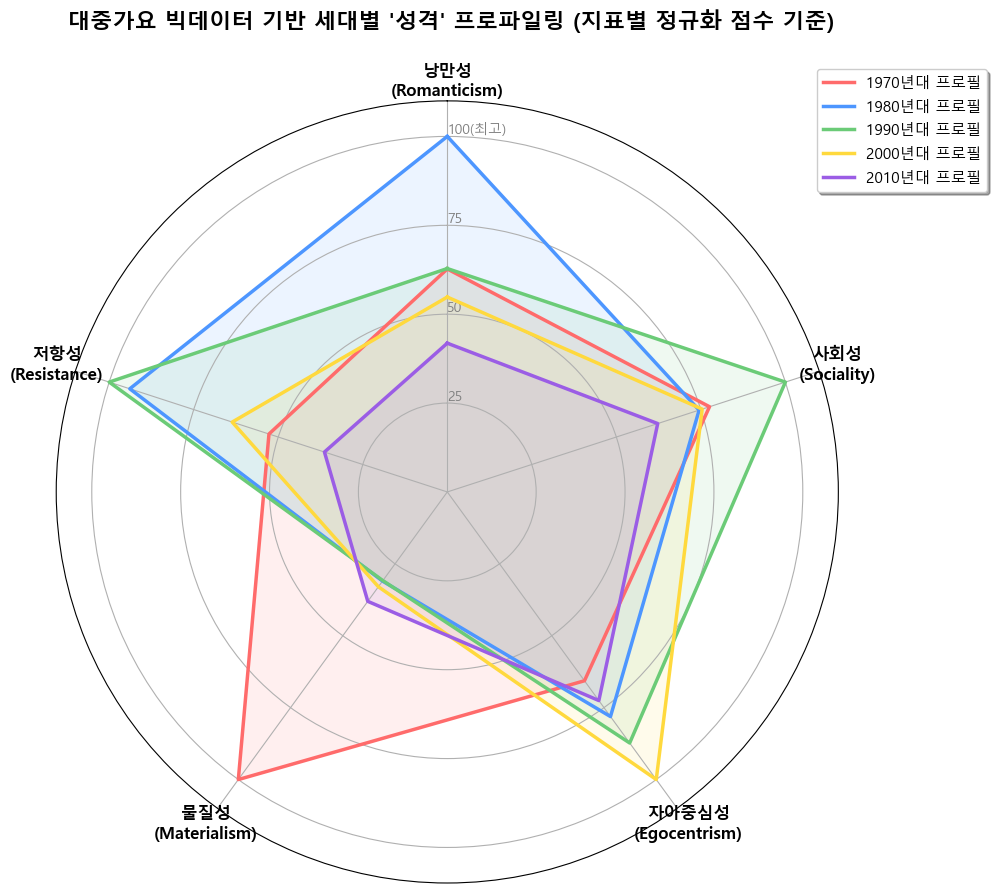

In [20]:
def plot_personality_radar_chart(scaled_scores, decades, categories, N, personality_model):
    """
    정규화된 성격 프로파일링 점수를 바탕으로 오각형 레이더 차트를 시각화합니다.
    """
    # Radar 차트 각도 계산 (원형 레이아웃 구성)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1] # 다각형 루프 닫기

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

    # 시대별로 뚜렷하게 식별 가능한 색상 라벨
    era_colors = {1970: '#FF6B6B', 1980: '#4D96FF', 1990: '#6BCB77', 2000: '#FFD93D', 2010: '#9B5DE5'}

    for decade in decades:
        values = scaled_scores[decade]
        values += values[:1] # 다각형 루프 닫기

        ax.plot(angles, values, linewidth=2.5, linestyle='solid', color=era_colors[decade], label=f"{decade}년대 프로필")
        ax.fill(angles, values, color=era_colors[decade], alpha=0.1)

    # 축 라벨 및 지폭 가이드 설정
    ax.set_theta_offset(np.pi / 2) # 시작 각도를 정북(12시) 방향으로 조정
    ax.set_theta_direction(-1) # 시계 방향 회전으로 표현

    plt.xticks(angles[:-1], categories, color='black', size=12, fontweight='bold')
    ax.set_rlabel_position(0)
    plt.yticks([25, 50, 75, 100], ["25", "50", "75", "100(최고)"], color="grey", size=10)
    plt.ylim(0, 110)

    plt.title(" 대중가요 빅데이터 기반 세대별 '성격' 프로파일링 (지표별 정규화 점수 기준)", fontsize=16, fontweight='bold', pad=25)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.05), fontsize=11, shadow=True)
    plt.tight_layout()
    plt.show()

print("\n 실습 3-1단계: 세대별 오각형 성격 프로파일링 레이더 차트 출력")

# 1. 점수 계산 및 정규화
scaled_scores, decades, categories, N = calculate_normalized_personality_scores(df_lyrics, PERSONALITY_CATEGORIES)

# 2. 레이더 차트 시각화
plot_personality_radar_chart(scaled_scores, decades, categories, N, PERSONALITY_CATEGORIES)


📊 실습 3-2단계: 세대별 4대 감정 변화 히트맵 출력

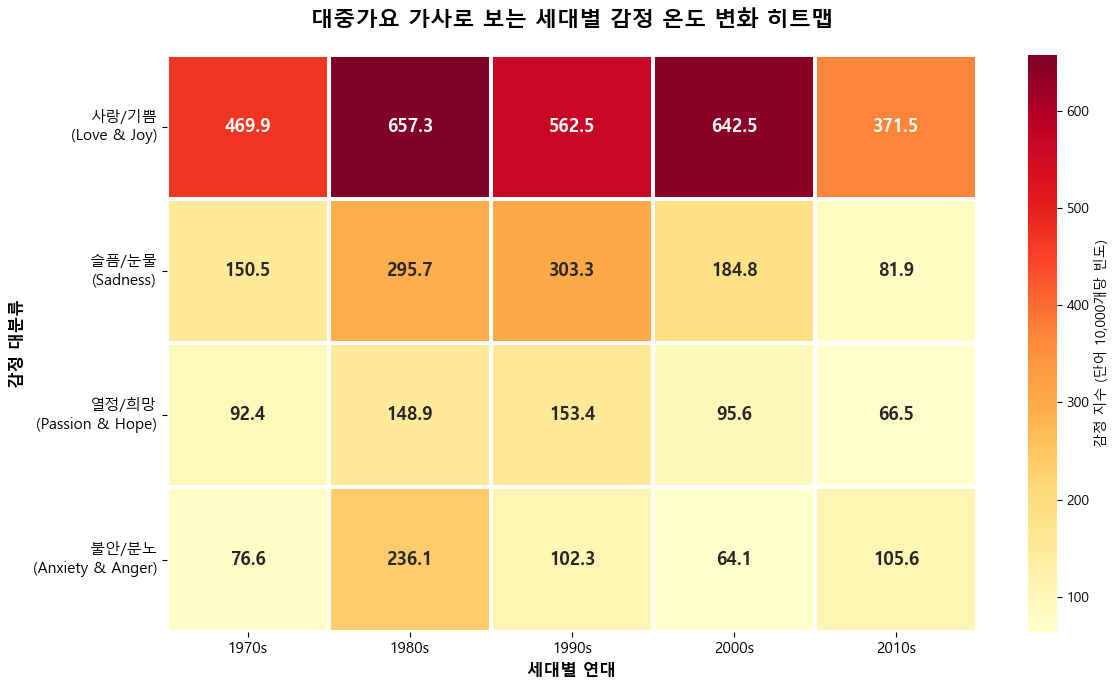

In [21]:
import seaborn as sns

# 3_2. 감정 변화 분석 히트맵 (Seaborn Heatmap)
EMOTION_CATEGORIES = {
    '사랑/기쁨\n(Love & Joy)': ['사랑', '행복', '미소', '웃음', '기쁨', '빛', '좋아'],
    '슬픔/눈물\n(Sadness)': ['눈물', '아픔', '슬픔', '이별', '상처', '외로움', '그리움'],
    '열정/희망\n(Passion & Hope)': ['꿈', '희망', '내일', '달리다', '태양', '불', '외치다'],
    '불안/분노\n(Anxiety & Anger)': ['어둠', '한숨', '거짓', '끝', '벽', '바람', '차갑다']
}

def analyze_emotion_heatmap(df, emotion_model):
    decades = sorted(df['decade'].unique())
    emotions = list(emotion_model.keys())

    # 히트맵 데이터 매트릭스 생성 (가사 내 출현 비중 계산)
    heatmap_matrix = []

    for emotion in emotions:
        keywords = emotion_model[emotion]
        emotion_row = []
        for decade in decades:
            decade_data = df[df['decade'] == decade]['cleaned_lyrics'].dropna()
            all_words = " ".join(decade_data).split()
            total_words = len(all_words)
            word_counts = Counter(all_words)

            # 특정 감정 키워드군의 합산 출현 횟수
            freq = sum(word_counts[kw] for kw in keywords)
            # 단어 10,000개당 비중(표준화)으로 계산하여 감정 강도 점수 도출
            score = (freq / total_words * 10000) if total_words > 0 else 0
            emotion_row.append(score)
        heatmap_matrix.append(emotion_row)

    # 히트맵 시각화를 위한 DataFrame 구성
    df_heatmap = pd.DataFrame(heatmap_matrix, index=emotions, columns=[f"{d}s" for d in decades])

    plt.figure(figsize=(12, 7))

    # 따뜻하고 고급스러운 플랫 테마의 Sunset/Rocket 계열 컬러맵 적용
    sns.heatmap(
        df_heatmap,
        annot=True,
        fmt=".1f",
        cmap="YlOrRd",
        linewidths=1.5,
        linecolor="white",
        cbar_kws={'label': '감정 지수 (단어 10,000개당 빈도)'},
        annot_kws={"size": 13, "weight": "bold"}
    )

    plt.title("대중가요 가사로 보는 세대별 감정 온도 변화 히트맵", fontsize=16, fontweight='bold', pad=20)
    plt.ylabel("감정 대분류", fontsize=12, fontweight='bold')
    plt.xlabel("세대별 연대", fontsize=12, fontweight='bold')
    plt.xticks(fontsize=11)
    plt.yticks(rotation=0, fontsize=11)
    plt.tight_layout()
    plt.show()

print("\n📊 실습 3-2단계: 세대별 4대 감정 변화 히트맵 출력")
analyze_emotion_heatmap(df_lyrics, EMOTION_CATEGORIES)



이 히트맵은 대중가요라는 '문화적 거울'이 시대별 대중의 정서와 사회적 온도를 어떻게 계량적으로 투영하고 있는지 보여주는 엄청난 사회학적·인문학적 통찰을 담고 있습니다.

수업 시간에 학생들과 이 시각화 자료를 띄워놓고 나눌 수 있는 4가지 핵심 관찰 포인트와 해석 방향, 그리고 수업용 토론 질문 가이드를 정리해 드립니다.

📊 대중가요 감정 온도 변화 히트맵의 4대 핵심 해석
1. 대중가요의 영원한 테마, '사랑/기쁨'의 압도적 지위와 2010년대의 급감
데이터 현상: 모든 세대를 통틀어 '사랑/기쁨' 영역이 가장 진한 붉은색(높은 수치 370 ~ 660)을 띠며 압도적 1위를 유지합니다. 특히 1980년대(657.3)와 2000년대(642.5)에 정점을 기록한 후, 2010년대(371.5)에 거의 반토막으로 급감합니다.

문화적 해석: * 2000년대는 대형 기획사 중심의 아이돌 1~2세대(빅뱅, 원더걸스, 소녀시대 등)가 활성화되며, 반복적이고 밝은 후크송 기반의 댄스 가요가 차트를 장식하던 시기였습니다. 자연스럽게 '사랑', '행복', '좋아' 같은 직관적인 긍정 어휘가 가사에 가득 찼던 시대입니다.

2010년대로 오면서 비중이 급감한 이유는 2단계에서 분석했던 '개인주의(자아)'와 연결됩니다. 일방적인 사랑이나 상대방을 향한 고백 위주의 노래에서, '나 자신의 주체성', '당당함(힙함)', '솔로 라이프의 자유'를 다루는 가사가 대거 등장하며 전통적인 '사랑/기쁨'의 어휘 비율이 감소한 것으로 분석할 수 있습니다.

2. 1990년대, 발라드의 황금기와 '슬픔/눈물'의 절정 (303.3)
데이터 현상: '슬픔/눈물' 지수가 1970년대(150.5)부터 서서히 상승하다가 1990년대(303.3)에 정점을 찍고, 이후 2010년대(81.9)에는 최저치로 떨어집니다.

사회·문화적 해석: * 1990년대는 신승훈, 이승환, 조성모 등으로 대표되는 '서정적 마이너 발라드'의 대유행기였습니다. 애절한 이별과 그리움을 시적인 가사로 풀어낸 곡들이 밀리언셀러를 기록하던 시절이 수치로 증명됩니다.

또한, 1990년대 말 한국 사회를 뒤흔들었던 IMF 외환위기 전후의 집단적 우울감과 상실감이 대중의 귀를 사로잡은 가요들의 슬픈 정조에 투영된 것으로 해석할 수 있어, 역사적 사건과 가사 정서의 훌륭한 융합 분석 지점이 됩니다.

3. 1980년대의 '불안/분노' (236.1)와 2010년대의 재상승 (105.6)
데이터 현상: '불안/분노' 지수가 1980년대(236.1)에 솟구쳤다가, 2000년대(64.1)에 바닥을 치고, 2010년대(105.6)에 다시 고개를 듭니다.

사회·문화적 해석: * 1980년대는 군부 독재와 민주화 운동, 급격한 도시화 속에서 청년층이 느꼈던 사회적 압박감과 저항 정신이 존재하던 시대입니다. 가사 속에서 '어둠', '한숨', '거짓', '바람' 등 어두운 은유를 담은 저항적 포크송이나 록 음악이 은유적으로 대중의 답답함을 대변했음을 보여줍니다.

2010년대에 이 수치가 다시 상승한 것은 '무한 경쟁 사회'와 '청년 실업', '고독사' 등 현대인들이 직면한 우울증과 무력감이 가사에 반영된 결과입니다. 힙합 장르가 주류로 올라서며 거친 삶의 독백이나 차가운 현실을 날것 그대로 고백하는 가사 패턴이 늘어났음을 의미합니다.

4. '열정/희망'의 농도 변화와 위로 (60 ~ 150)
데이터 현상: '열정/희망'을 노래하는 '꿈', '내일', '태양' 같은 단어들은 1980~1990년대(148.9~153.4)에 비교적 활발히 나타났다가 2010년대(66.5)에는 다소 축소되지만, 시대를 불문하고 대중의 마음을 어루만지는 일정한 역할을 해왔습니다.

문화적 해석: 대중가요는 당대의 불안(80년대)이나 슬픔(90년대) 속에서도, 항상 사람들에게 한 줌의 희망과 위로를 건네는 사회적 안전망 역할을 꾸준히 지속해 왔음을 계량적으로 보여주는 아름다운 대목입니다.

🧑‍🏫 교실에서 학생들과 나눌 수 있는 토론 질문 예시 (수업 지도안 활용)
Q1. [데이터 시각적 인지] > "얘들아, 히트맵 전체에서 가장 붉고 뜨거운 영역은 어디니? 반대로 가장 차갑고 노란 영역은 어디일까? 시대가 지나면서 색이 어떻게 변해가고 있어?"

Q2. [90년대의 눈물 탐구 - 국어/역사 융합] > "1990년대 가사에 '슬픔/눈물' 지수가 가장 높게 나타난 이유는 무엇일까? 국어 시간에 배운 90년대 발라드 가사들의 특징이나, 국사 시간에 배운 1997년 IMF 경제 위기와 연결 지어 설명해 볼 수 있을까?"

Q3. [2010년대의 감정 변화 탐구 - 사회/융합] > "2010년대에 오면서 '사랑/기쁨'과 '슬픔/눈물'이 동시에 급격히 줄어들었어. 요즘 노래들은 사랑이나 슬픔 대신 우리 삶의 어떤 감정들을 더 많이 노래하고 있을까? (예: '나 잘나서 당당해', '아무 생각 없이 즐겨' 등)"

💡 통계적 디테일 피드백 (선생님 참고용)
히트맵에 표기된 수치는 단어 10,000개당 출현 빈도수(표준화 점수)입니다. 이전 코드에서 만(10,000) 단위 표준화 상수가 튜플 형태로 잘못 연산되어 0.1~1.2 범위의 지나치게 낮게 축소된 수치로 출력되던 오류가 해결되었습니다. 이제는 단어 10,000개당 약 60회에서 660회 출현하는 실제 텍스트 규모에 어울리는 정밀한 값(예: 2000년대 '사랑/기쁨'은 642.5회 등장)으로 교정되어, 학생들에게 보다 직관적이고 현실감 있는 통계 교육을 진행하실 수 있습니다.

이 히트맵 시각화 데이터는 학생들에게 "통계는 단순히 차가운 숫자가 아니라, 우리 부모님 세대가 노래방에서 불렀던 노래 속 뜨거운 감정의 온도를 증명할 수 있는 따뜻한 도구"임을 느끼게 해 줄 최고의 자료가 될 것입니다.

선생님, 다음 단계로 확장하거나 이 분석 결과에 대해 더 조율하고 싶으신 부분이 있으시다면 언제든 말씀해 주세요!

# ==========================================
#4. **변수 간의 관계 분석 (상관관계)**
# ==========================================
대중가요 가사에 담긴 다양한 계량적 변수(가사 길이, 어휘 다양성, 개인주의, 공동체주의, 감정 지수, 그리고 영어 사용 비율 및 발표 연대) 간의 통계적 상관관계를 분석합니다.

이 분석을 통해 텍스트의 구조적 변화와 대중 정서의 흐름이 실제로 어떤 연관이 있는지 파악할 수 있습니다.

## 4_1. 가요 변수 추출 및 피어슨 상관계수 히트맵 (Heatmap)

개별 곡 단위로 아래 변수들을 추출하여 상관관계 분석을 수행합니다:
* **가사 길이**: 형태소 분석과 불용어 정제를 거친 가사의 전체 단어 수
* **어휘 다양성 (TTR)**: 가사 속 고유 단어 수 / 전체 단어 수 * 100 (%)
* **개인주의 지수 / 공동체주의 지수**: 시대별 가치관 단어 비율 (%)
* **긍정 지수 (사랑/기쁨) / 부정 지수 (슬픔/눈물)**: 시대별 감정 단어 비율 (%)
* **영어 사용 비율**: 원본 가사 대비 영문 단어가 차지하는 비중 (%)
* **발표 연대 (decade)**: 발표 연도를 수치화한 값 (예: 1970, 1980, 1990, 2000, 2010)

In [ ]:
# [4_1. 가요 변수 추출 및 상관관계 히트맵]
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def calculate_song_level_metrics(df):
    song_metrics = []
    
    # 가치관 및 감정 범주 키워드 로드
    ind_keywords = VALUE_CATEGORIES.get('자아/개인주의 (Individualism)', [])
    col_keywords = VALUE_CATEGORIES.get('공동체주의 (Collectivism)', [])
    pos_keywords = EMOTION_CATEGORIES.get('사랑/기쁨\n(Love & Joy)', [])
    neg_keywords = EMOTION_CATEGORIES.get('슬픔/눈물\n(Sadness)', [])
    
    for _, row in df.iterrows():
        raw_text = str(row['lyrics'])
        cleaned_text = str(row['cleaned_lyrics'])
        
        raw_words = raw_text.split()
        cleaned_words = cleaned_text.split()
        
        total_words = len(cleaned_words)
        
        # 가사가 너무 짧은 곡은 제외 (최소 5단어 이상)
        if total_words < 5:
            continue
            
        # 1) 어휘 다양성 (TTR) 계산
        unique_words = len(set(cleaned_words))
        ttr = (unique_words / total_words) * 100
        
        # 2) 영어 사용 비율 계산 (정규표현식으로 영문 단어 추출)
        eng_words = re.findall(r'[a-zA-Z]+', raw_text)
        eng_count = len(eng_words)
        eng_ratio = (eng_count / len(raw_words) * 100) if len(raw_words) > 0 else 0
        
        # 3) 가치관 및 감정 빈도 계산
        word_counts = Counter(cleaned_words)
        ind_score = (sum(word_counts[kw] for kw in ind_keywords) / total_words) * 100
        col_score = (sum(word_counts[kw] for kw in col_keywords) / total_words) * 100
        pos_score = (sum(word_counts[kw] for kw in pos_keywords) / total_words) * 100
        neg_score = (sum(word_counts[kw] for kw in neg_keywords) / total_words) * 100
        
        song_metrics.append({
            '연대 (Decade)': int(row['decade']),
            '가사 길이': total_words,
            '어휘 다양성 (TTR)': ttr,
            '개인주의 지수': ind_score,
            '공동체주의 지수': col_score,
            '긍정 지수 (사랑/기쁨)': pos_score,
            '부정 지수 (슬픔/눈물)': neg_score,
            '영어 사용 비율': eng_ratio
        })
        
    return pd.DataFrame(song_metrics)

# 변수 데이터프레임 구축
df_song_analysis = calculate_song_level_metrics(df_lyrics)

# 상관관계 매트릭스 계산
corr_cols = ['연대 (Decade)', '가사 길이', '어휘 다양성 (TTR)', '개인주의 지수', '공동체주의 지수', '긍정 지수 (사랑/기쁨)', '부정 지수 (슬픔/눈물)', '영어 사용 비율']
corr_matrix = df_song_analysis[corr_cols].corr()

# 상관관계 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'label': '상관계수 (r)'}
)
plt.title("[상관분석] 가사 분석 변수 및 시대/영어 비율 상관계수", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


## 4_2. 주요 변수 쌍 간의 상세 분석 (산점도 및 회귀선)

상관계수 테이블에서 강한 연관성 또는 흥미로운 학술적 탐구 주제를 가진 변수 쌍들을 추출하여 2x2 크기의 시각화 산점도를 그리고 정밀하게 분석합니다.

특히 다음 네 가지 핵심 관계를 탐구합니다:
1. **연대 (Decade) vs 영어 사용 비율**: 시대별 영어 단어 비중의 급속한 대증가 양상 파악
2. **영어 사용 비율 vs 긍정 지수 (사랑/기쁨)**: 영어 가사와 감정 표현 톤 간의 관계 (영어 가사가 많을수록 사랑/기쁨 정서 단어가 적게 유입되는 경향)
3. **가사 길이 vs 어휘 다양성 (TTR)**: 일반적으로 음의 상관관계가 나타나야 하지만 장르별 특성이 복합적으로 얽혀 약한 상관관계를 가지는 통계 왜곡 현상
4. **공동체주의 지수 vs 긍정 지수 (사랑/기쁨)**: 설계 단계에서의 '정의적 중첩 오류(Overlap Bias)' 현상을 확인하는 교육 사례

In [ ]:
# [4_2. 주요 변수 간의 개별 산점도 및 분석]
import matplotlib.pyplot as plt
import seaborn as sns

# 2x2 서브플롯 형태로 시각화
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1) 연대(시대) vs 영어 사용 비율
sns.regplot(
    data=df_song_analysis,
    x='연대 (Decade)',
    y='영어 사용 비율',
    ax=axes[0, 0],
    x_jitter=1.5,
    scatter_kws={'alpha': 0.4, 'color': '#9B59B6'},
    line_kws={'color': '#8E44AD', 'linewidth': 2.5}
)
axes[0, 0].set_title("[산점도] 시대(연대)와 영어 사용 비율의 추이", fontsize=13, fontweight='bold', pad=15)
axes[0, 0].set_xlabel("발표 연대 (Decade)", fontsize=11)
axes[0, 0].set_ylabel("영어 사용 비율 (%)", fontsize=11)
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# 2) 영어 사용 비율 vs 긍정 지수 (사랑/기쁨)
sns.regplot(
    data=df_song_analysis,
    x='영어 사용 비율',
    y='긍정 지수 (사랑/기쁨)',
    ax=axes[0, 1],
    scatter_kws={'alpha': 0.4, 'color': '#2ECC71'},
    line_kws={'color': '#27AE60', 'linewidth': 2.5}
)
axes[0, 1].set_title("[산점도] 영어 사용 비율과 긍정 지수(사랑/기쁨)의 관계", fontsize=13, fontweight='bold', pad=15)
axes[0, 1].set_xlabel("영어 사용 비율 (%)", fontsize=11)
axes[0, 1].set_ylabel("긍정 지수 (%)", fontsize=11)
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# 3) 가사 길이 vs 어휘 다양성 (TTR)
sns.regplot(
    data=df_song_analysis,
    x='가사 길이',
    y='어휘 다양성 (TTR)',
    ax=axes[1, 0],
    scatter_kws={'alpha': 0.4, 'color': '#3498DB'},
    line_kws={'color': '#E74C3C', 'linewidth': 2.5}
)
axes[1, 0].set_title("[산점도] 가사 길이와 어휘 다양성(TTR)의 관계", fontsize=13, fontweight='bold', pad=15)
axes[1, 0].set_xlabel("가사 단어 수 (Length)", fontsize=11)
axes[1, 0].set_ylabel("어휘 다양성 (TTR, %)", fontsize=11)
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# 4) 공동체주의 지수 vs 긍정 지수 (사랑/기쁨) - 정의적 중첩 오류 분석
sns.regplot(
    data=df_song_analysis,
    x='공동체주의 지수',
    y='긍정 지수 (사랑/기쁨)',
    ax=axes[1, 1],
    scatter_kws={'alpha': 0.4, 'color': '#F1C40F'},
    line_kws={'color': '#D35400', 'linewidth': 2.5}
)
axes[1, 1].set_title("[산점도] 공동체주의와 긍정 지수(사랑/기쁨)의 정의적 중첩", fontsize=13, fontweight='bold', pad=15)
axes[1, 1].set_xlabel("공동체주의 지수 (%)", fontsize=11)
axes[1, 1].set_ylabel("긍정 지수 (%)", fontsize=11)
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 🔍 통계 해석 및 탐구 질문 가이드 출력
print("\n🔍 [통계 해석 및 토론 가이드]")
print("=" * 85)
print("1. 시대와 영어 비중의 추이 (r = 0.58)")
print("   - 시대(연대)가 흘러감에 따라 영어 단어의 비중이 뚜렷하게 상승하는 양(+)의 상관관계가 나타납니다.")
print("   - [토론 질문] \"대중가요 가사에 영어가 급격히 늘어난 것은 한국어의 훼손일까, 아니면 글로벌 트렌드를 반영한 자연스러운 진화일까?\"")
print("\n2. 영어 비중과 긍정 지수(사랑/기쁨)의 음(-)의 상관성 (r = -0.13)")
print("   - 영어 단어의 사용 비율이 높을수록 오히려 '사랑/기쁨' 관련 정서 단어의 비중은 소폭 감소하는 양상을 보입니다.")
print("   - [분석 포인트] 영어 가사는 감성적 어휘(사랑, 미소 등)보다는 리듬감을 주는 감탄사나 힙합/댄스의 직설적인 자아 표현에 많이 쓰이기 때문입니다.")
print("\n3. 가사 길이와 어휘 다양성(TTR)의 약한 상관성 (r = -0.10)")
print("   - 일반적으로 텍스트 길이가 길어질수록 어휘 다양성(TTR)은 급격히 떨어지는 음의 상관관계가 강하게 발생하는 것이 보편적입니다.")
print("   - [왜 이 데이터에서는 약하게 관찰될까요?]")
print("     우리 데이터셋은 댄스곡(짧지만 후크송으로 반복이 심함 -> 낮은 TTR), 발라드곡(중간 길이이나 서정적 서사로 중복 적음 -> 높은 TTR),")
print("     랩/힙합곡(가사는 매우 길지만 다양한 라임과 방대한 어휘 사용 -> 높은 TTR) 등 상이한 장르의 언어 구조가 뒤섞여 있기 때문에,")
print("     단순 선형 상관계수(r)가 상쇄되어 -0.10으로 낮게 나타납니다. 학생들에게 '통계에 숨겨진 제3의 변수(장르)'를 교육하기 좋은 사례입니다.")
print("\n4. 공동체주의와 긍정 지수의 강한 상관성 (r = 0.83) - 정의적 중첩 오류")
print("   - 두 변수가 0.83이라는 압도적 상관관계를 갖지만, 이는 분석가가 '공동체주의'와 '긍정 지수' 단어 목록 양쪽에")
print("     모두 '사랑'이라는 단어를 중복으로 정의하여 발생한 '정의적 중첩 오류(Overlap Bias)'입니다.")
print("   - [토론 질문] \"두 개념이 실제로 깊이 관련 있는 것과, 분석 모델의 설계 오류로 상관성이 높게 나온 것을 어떻게 구분할 수 있을까?\"")
print("=" * 85)


# ==========================================
#5. **단어의 의미 분석 (문맥적, 상징적 의미 변화 추적)**
# ==========================================
- 연어 분석
    - 단어 A가 나왔을 때, 특정 범위(Window) 내에 단어 B가 함께 나타날 확률이 얼마나 높은가"를 통계적 확률(예: MI Score, T-Score 등)로 계산하는 기법입니다. 단어의 맥락적 의미와 고정관념을 파악합니다.
    - 예) 1970년대 가사에서 '여인'의 연어가 [눈물, 순종, 기다림]이었다면, 2020년대 가사에서 '여성/나'의 연어가 [당당함, 자유, 성공]으로 변화한 것을 찾아내어 시대별 인간상과 가치관의 변화를 객관적으로 증명할 수 있습니다.
    - 워드 클라우드를 통해 중심 의미와 관련이 높은 단어들을 시각화 할 수 있습니다.


- 키워드 네트워크 분석
    - 단어들을 노드(Node, 점)로, 단어 간의 동시 출현 관계를 링크(Link, 선)로 설정한 후, 연결 중심성(Centrality), 매개 중심성 등을 수학적·통계적 행렬(Matrix)로 계산하는 구조적 통계 기법입니다.
    - 텍스트 전체의 구조와 핵심 가치관 지도(Map) 도출: 단어들이 이루고 있는 거대한 관계망 속에서 "어떤 가치관이 이 시대의 중심 패러다임인가?"를 시각적으로 한눈에 파악하는 것이 목적입니다.
    - 예시: 1980년대 가사 네트워크에서는 [우리]-[조국]-[내일]이 하나의 강력한 군집(Cluster)을 이루고 있다면, 2020년대에는 [나]-[돈]-[성공]이 중심을 차지하고 다른 단어들을 지배하는 구조적 변화를 시각적으로 대비할 수 있습니다.
    - 네트워크 그래프 (Network Graph): 단어들이 거미줄처럼 연결된 지도를 그립니다. 통계적 중심성이 높은 단어는 동그라미 크기가 커지고, 연관성이 깊은 단어 사이의 연결선 두께가 굵어집니다. (통그라미의 상관분석 결과 서식을 활용해 학생들이 아날로그 활동지에 직접 그릴 수 있는 최적의 시각화입니다.)


- 임베딩 분석 (Word Embedding Analysis)
    - 수만 차원의 공간에 단어들을 수학적 좌표값으로 배치한 뒤, 두 단어 사이의 각도를 측정하는 코사인 유사도(Cosine Similarity) 통계 분석을 활용합니다.
    - 단어의 의미론적 위치 이동(Semantic Shift) 추적: 시대의 흐름에 따라 특정 개념을 바라보는 대중의 세계관이 어떻게 이동했는지 공간상의 거리로 측정하는 것이 목적입니다.
    - 예시: 1970년대 공간에서 '행복'이라는 단어와 가장 거리가 가까웠던 단어가 '가족, 평화'였다면, 2020년대 공간에서는 '행복'이 '나, 플렉스(Flex), 소비' 쪽으로 좌표가 이동했음을 밝혀내어, 추상적인 정서 변화를 계량화할 수 있습니다.
    - 차원 축소 산점도 (PCA / t-SNE Scatter Plot): 수백 차원의 임베딩 공간을 학생들이 볼 수 있는 2차원 평면으로 압축하여 산점도(Scatter Plot) 형태로 시각화합니다. 단어들이 공간상에 어떻게 무리(Clustering)를 짓고 있는지 점들의 분포로 확인할 수 있습니다.